# Unified Multi-Asset TDA Forecasting & Quantitative Trading Framework 

A leak-free, statistically grounded, and execution-realistic pipeline combining Topological Data Analysis (TDA) with machine learning for multi-asset market regime forecasting and systematic strategy evaluation.




## 1. Environment Setup & Package Installation
Configures the runtime environment and installs required libraries (`yfinance`, `ripser`, `persim`, `lightgbm`, `shap`).


In [1]:

import os
import sys

IN_KAGGLE = os.path.exists("/kaggle/input")
if IN_KAGGLE:
    for dirname, _, filenames in os.walk("/kaggle/input"):
        for filename in filenames:
            print(os.path.join(dirname, filename))

print("Python:", sys.version.split()[0])
print("Kaggle environment:", IN_KAGGLE)


Python: 3.12.13
Kaggle environment: True


In [2]:
!pip install yfinance ripser persim lightgbm shap --quiet


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 843.4/843.4 kB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.6/48.6 kB 3.2 MB/s eta 0:00:00


## 2. Imports, Seeds & Device Setup
Loads dependencies, establishes seed management for strict reproducibility, and configures compute hardware with safe fallback.


In [3]:
from __future__ import annotations

import json
import hashlib
import warnings
from dataclasses import dataclass, field
from typing import Any, Dict, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.ndimage import zoom
from scipy.spatial import cKDTree

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    log_loss,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
    mutual_info_score,
)

import yfinance as yf
from ripser import ripser
from persim import PersistenceImager, wasserstein

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


def seed_everything(seed: int) -> None:
    """Set all random seeds for reproducible execution."""
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


# Device configuration with safe CUDA check
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
try:
    if torch.cuda.is_available():
        _test_t = torch.zeros(1, device=DEVICE)
        print("Torch:", torch.__version__, "| device:", DEVICE, f"({torch.cuda.get_device_name(0)})")
    else:
        print("Torch:", torch.__version__, "| device:", DEVICE)
except Exception as e:
    DEVICE = torch.device("cpu")
    print(f"CUDA check failed ({e}); falling back to CPU mode.")


Torch: 2.10.0+cu128 | device: cuda (Tesla T4)


## 3. Global Configuration
Central dataclass controlling data parameters, TDA scales, cross-validation, hyperparameter bounds, and execution mode.


In [4]:
@dataclass
class Config:
    # ---- reproducibility -------------------------------------------------
    seed: int = 42

    # ---- universe (multi-asset panel) ------------------------------------
    tickers_equity: List[str] = field(
        default_factory=lambda: ["SPY", "QQQ", "DIA", "IWM"]
    )
    tickers_macro: List[str] = field(default_factory=lambda: ["^VIX", "^TNX"])
    primary_ticker: str = "SPY"
    start_date: str = "2005-01-01"
    end_date: str = "2025-08-28"

    # ---- labels ----------------------------------------------------------
    # "3class" -> Short / Cash / Long, volatility gated
    # "binary" -> Down / Up
    label_mode: str = "3class"
    horizon: int = 1
    vol_threshold_mult: float = 0.5
    vol_window: int = 20

    # ---- topology --------------------------------------------------------
    tda_windows: List[int] = field(default_factory=lambda: [30, 45, 60])
    point_cloud_modes: List[str] = field(
        default_factory=lambda: ["multivariate", "takens"]
    )
    n_betti_bins: int = 10
    n_landscape_layers: int = 5
    landscape_resolution: int = 100
    persistence_image_shape: Tuple[int, int] = (10, 10)
    persistence_image_raw_bins: int = 20
    use_persistence_images: bool = True
    max_wasserstein_points: int = 30
    max_embed_dim: int = 10
    max_ami_lag: int = 20
    min_cloud_points: int = 12
    zscore_min_periods: int = 60
    zscore_clip: float = 10.0

    # ---- validation ------------------------------------------------------
    split_mode: str = "walkforward"      # "walkforward" | "holdout"
    train_years: int = 5
    test_years: int = 1
    val_fraction: float = 0.2            # tail of each training block
    holdout_train: float = 0.70
    holdout_val: float = 0.85

    # ---- training --------------------------------------------------------
    batch_size: int = 64
    epochs: int = 60
    learning_rate: float = 5e-4
    weight_decay: float = 1e-4
    patience: int = 8
    dropout: float = 0.25
    focal_gamma: float = 2.0             # 0.0 -> weighted cross-entropy
    grad_clip: float = 1.0

    # ---- backtest --------------------------------------------------------
    cost_grid_bps: List[float] = field(
        default_factory=lambda: [0.0, 1.0, 5.0, 10.0, 20.0]
    )
    headline_cost_bps: float = 1.0
    signal_mode: str = "threshold"       # "threshold" | "argmax"
    prob_floor: float = 0.45             # 3-class entry threshold
    prob_margin: float = 0.10            # required edge over opposite side
    binary_threshold: float = 0.50
    trading_days: int = 252

    # ---- statistical rigor & multiple testing ----------------------------
    stability_seeds: List[int] = field(
        default_factory=lambda: [13, 42, 101, 2024, 777, 3407, 8, 99]
    )
    n_bootstrap: int = 5000
    n_total_trials_dsr: int = 60         # Total trials explored for Deflated Sharpe Ratio
    fdr_alpha: float = 0.05

    # ---- io --------------------------------------------------------------
    plot_dir: str = "./plots"
    cache_dir: str = "./cache"
    use_cache: bool = True

    @property
    def all_tickers(self) -> List[str]:
        return self.tickers_equity + self.tickers_macro

    @property
    def n_classes(self) -> int:
        return 3 if self.label_mode == "3class" else 2

    @property
    def chance_baseline(self) -> float:
        return 1.0 / self.n_classes

    @property
    def seq_len(self) -> int:
        return max(self.tda_windows)


# Set FAST_MODE = False for the full 8-seed x 3-scale thesis run
FAST_MODE = False

CFG = Config()
if FAST_MODE:
    CFG.tda_windows = [30, 60]
    CFG.epochs = 30
    CFG.patience = 5
    CFG.stability_seeds = [13, 42, 101]
    CFG.n_bootstrap = 2000

os.makedirs(CFG.plot_dir, exist_ok=True)
os.makedirs(CFG.cache_dir, exist_ok=True)
seed_everything(CFG.seed)

print(f"FAST_MODE          : {FAST_MODE}")
print(f"Universe           : {CFG.all_tickers}")
print(f"Label mode         : {CFG.label_mode} ({CFG.n_classes} classes, chance baseline = {CFG.chance_baseline:.1%})")
print(f"Topological scales : {CFG.tda_windows}")
print(f"Point cloud modes  : {CFG.point_cloud_modes}")
print(f"Sequence length    : {CFG.seq_len}")
print(f"Validation         : {CFG.split_mode}")
print(f"Stability seeds    : {len(CFG.stability_seeds)} seeds -> {CFG.stability_seeds}")


def savefig(name: str) -> None:
    """Save figure to plot directory."""
    plt.savefig(os.path.join(CFG.plot_dir, f"{name}.png"), dpi=150, bbox_inches="tight")


FAST_MODE          : False
Universe           : ['SPY', 'QQQ', 'DIA', 'IWM', '^VIX', '^TNX']
Label mode         : 3class (3 classes, chance baseline = 33.3%)
Topological scales : [30, 45, 60]
Point cloud modes  : ['multivariate', 'takens']
Sequence length    : 60
Validation         : walkforward
Stability seeds    : 8 seeds -> [13, 42, 101, 2024, 777, 3407, 8, 99]


## 4. Data Ingestion & Multi-Asset Panel Construction
Downloads daily OHLCV bars across equity and macro assets, constructs technical indicators, and applies causal expanding winsorization to eliminate lookahead bias.


In [5]:
def download_multi_asset_data(
    tickers: Sequence[str], start: str, end: str
) -> Dict[str, pd.DataFrame]:
    """Download daily OHLCV bars for each ticker via yfinance."""
    data: Dict[str, pd.DataFrame] = {}
    for ticker in tickers:
        print(f"  downloading {ticker} ...")
        df = yf.download(ticker, start=start, end=end, auto_adjust=True, progress=False)
        if df is None or len(df) == 0:
            raise ValueError(f"No data returned for {ticker}")
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        df = df[["Open", "High", "Low", "Close", "Volume"]].copy()
        df.index = pd.to_datetime(df.index)
        data[ticker] = df.sort_index()
    return data


def compute_log_returns(close: pd.Series) -> pd.Series:
    """r_t = ln(P_t / P_{t-1})."""
    return np.log(close) - np.log(close.shift(1))


def compute_rsi(close: pd.Series, period: int = 14) -> pd.Series:
    """Relative Strength Index."""
    delta = close.diff()
    gain = delta.clip(lower=0).rolling(period).mean()
    loss = (-delta.clip(upper=0)).rolling(period).mean()
    rs = gain / (loss + 1e-9)
    return 100.0 - (100.0 / (1.0 + rs))


def compute_macd(
    close: pd.Series, fast: int = 12, slow: int = 26, signal: int = 9
) -> Tuple[pd.Series, pd.Series, pd.Series]:
    """MACD line, signal line, and histogram."""
    ema_fast = close.ewm(span=fast, adjust=False).mean()
    ema_slow = close.ewm(span=slow, adjust=False).mean()
    macd_line = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    return macd_line, signal_line, macd_line - signal_line


def compute_bollinger_width(close: pd.Series, window: int = 20) -> pd.Series:
    """Normalized 2-sigma Bollinger band width."""
    sma = close.rolling(window).mean()
    sd = close.rolling(window).std()
    return (4.0 * sd) / (sma + 1e-9)


def compute_technical_features(
    close: pd.Series, volume: pd.Series, log_ret: pd.Series, vol_window: int
) -> pd.DataFrame:
    """Eight technical descriptors per asset."""
    macd_line, macd_signal, macd_hist = compute_macd(close)
    negative = log_ret.clip(upper=0)
    return pd.DataFrame(
        {
            "rsi": compute_rsi(close),
            "macd": macd_line,
            "macd_signal": macd_signal,
            "macd_hist": macd_hist,
            "rolling_vol": log_ret.rolling(vol_window).std(),
            "semi_var": (negative ** 2).rolling(vol_window).mean(),
            "bb_width": compute_bollinger_width(close, vol_window),
            "volume_change": np.log(volume + 1.0).diff(),
        },
        index=close.index,
    )


def causal_interpolate(series: pd.Series) -> pd.Series:
    """Strictly causal gap filling (forward-fill then back-fill leading NaNs)."""
    return series.ffill().bfill()


def winsorize_series(
    series: pd.Series, limits: Tuple[float, float] = (0.01, 0.01), min_periods: int = 60
) -> pd.Series:
    """Causal expanding-window winsorization to prevent backward leakage."""
    if series.isna().all():
        return series
    lo = series.expanding(min_periods=min_periods).quantile(limits[0])
    hi = series.expanding(min_periods=min_periods).quantile(1.0 - limits[1])
    clipped = series.clip(lower=lo, upper=hi)
    return clipped.fillna(series)


def build_panel(
    raw_data: Dict[str, pd.DataFrame], cfg: Config
) -> Tuple[pd.DataFrame, List[str], List[str]]:
    """Inner-join all assets on a shared calendar and assemble feature matrix."""
    common_idx: Optional[pd.Index] = None
    for df in raw_data.values():
        common_idx = df.index if common_idx is None else common_idx.intersection(df.index)
    common_idx = common_idx.sort_values()

    frames: List[pd.DataFrame] = []
    return_cols: List[str] = []
    tech_cols: List[str] = []
    primary_close: Optional[pd.Series] = None

    for ticker in cfg.all_tickers:
        df = raw_data[ticker].loc[common_idx]
        close = causal_interpolate(df["Close"].astype(float))
        volume = df["Volume"].astype(float).fillna(0.0)
        log_ret = causal_interpolate(compute_log_returns(close))
        tech = compute_technical_features(close, volume, log_ret, cfg.vol_window)

        log_ret = winsorize_series(log_ret)
        for col in tech.columns:
            tech[col] = winsorize_series(tech[col])

        prefix = ticker.replace("^", "")
        log_ret.name = f"{prefix}_logret"
        tech.columns = [f"{prefix}_{c}" for c in tech.columns]

        return_cols.append(log_ret.name)
        tech_cols.extend(list(tech.columns))
        frames.append(pd.concat([log_ret, tech], axis=1))

        if ticker == cfg.primary_ticker:
            primary_close = close.copy()

    panel = pd.concat(frames, axis=1)
    panel["PRIMARY_Close"] = primary_close
    panel = panel.dropna()

    print(f"  panel shape : {panel.shape}")
    print(f"  date range  : {panel.index.min().date()} -> {panel.index.max().date()}")
    return panel, return_cols, tech_cols


In [6]:
print("Downloading multi-asset data ...")
raw_data = download_multi_asset_data(CFG.all_tickers, CFG.start_date, CFG.end_date)
panel, RETURN_COLS, TECH_COLS = build_panel(raw_data, CFG)

FEATURE_COLS = RETURN_COLS + TECH_COLS
panel.to_csv("preprocessed_data.csv")

print(f"\nReturn columns    ({len(RETURN_COLS)}): {RETURN_COLS}")
print(f"Technical columns ({len(TECH_COLS)}) e.g. {TECH_COLS[:4]} ...")
print(f"Sequence features ({len(FEATURE_COLS)}) saved to preprocessed_data.csv")
panel.head()


  downloading SPY ...
  downloading QQQ ...
  downloading DIA ...
  downloading IWM ...
  downloading ^VIX ...
  downloading ^TNX ...
  panel shape : (5172, 55)
  date range  : 2005-01-31 -> 2025-08-27

Return columns    (6): ['SPY_logret', 'QQQ_logret', 'DIA_logret', 'IWM_logret', 'VIX_logret', 'TNX_logret']
Technical columns (48) e.g. ['SPY_rsi', 'SPY_macd', 'SPY_macd_signal', 'SPY_macd_hist'] ...
Sequence features (54) saved to preprocessed_data.csv


,SPY_logret,SPY_rsi,SPY_macd,SPY_macd_signal,SPY_macd_hist,SPY_rolling_vol,SPY_semi_var,SPY_bb_width,SPY_volume_change,QQQ_logret,...,TNX_logret,TNX_rsi,TNX_macd,TNX_macd_signal,TNX_macd_hist,TNX_rolling_vol,TNX_semi_var,TNX_bb_width,TNX_volume_change,PRIMARY_Close
Date,,,,,,,,,,,,,,,,,,,,,
2005-01-31,0.006197,45.081999,-0.416809,-0.442272,0.025463,0.006730,0.000033,0.031639,-0.145149,0.012917,...,-0.001209,30.562987,-0.020176,-0.013518,-0.006658,0.008465,0.000030,0.050385,0.000000,79.730583
2005-02-01,0.006328,54.309483,-0.322915,-0.418401,0.095486,0.006442,0.000025,0.027179,-0.052594,0.003203,...,0.000726,34.210554,-0.021932,-0.015200,-0.006731,0.007691,0.000030,0.052633,11.969724,80.236679
2005-02-02,0.003023,54.146790,-0.226296,-0.379980,0.153684,0.005860,0.000018,0.028170,0.051379,0.001598,...,0.000967,35.798779,-0.022738,-0.016708,-0.006030,0.006759,0.000030,0.051293,0.000000,80.479568
2005-02-03,-0.002602,58.590089,-0.164701,-0.336924,0.172223,0.005660,0.000016,0.029034,-0.071730,-0.011508,...,0.005540,46.153891,-0.021276,-0.017622,-0.003654,0.006950,0.000030,0.048540,0.000000,80.270439
2005-02-04,0.010619,61.774891,-0.046208,-0.278781,0.232573,0.006025,0.000016,0.033125,0.024025,0.016022,...,-0.021856,30.831064,-0.027067,-0.019511,-0.007557,0.008325,0.000053,0.051316,0.000633,81.127350


## 5. Sliding Windows, Canonical Index Map & Target Labels
Derives canonical sequence arrays, forward returns with realistic 1-bar execution delay, and volatility-gated discrete class targets.


In [7]:
LABEL_NAMES = {
    "3class": ["Short", "Cash", "Long"],
    "binary": ["Down", "Up"],
}


def build_supervised_dataset(
    panel: pd.DataFrame,
    feature_cols: Sequence[str],
    return_cols: Sequence[str],
    cfg: Config,
) -> Dict[str, Any]:
    """Construct sequence tensors, forward returns, and labels with a 1-bar execution delay."""
    values = panel[list(feature_cols)].values.astype(np.float64)
    returns = panel[list(return_cols)].values.astype(np.float64)
    close = panel["PRIMARY_Close"].values.astype(np.float64)

    vol_col = f"{cfg.primary_ticker.replace('^', '')}_rolling_vol"
    sigma = panel[vol_col].values.astype(np.float64)

    n_rows = len(panel)
    w_max = cfg.seq_len
    horizon = cfg.horizon

    # 1-bar execution delay: decision at e-1, trade at e, payoff e -> e+h
    ends = np.arange(w_max, n_rows - horizon)
    if len(ends) == 0:
        raise ValueError("Panel too short for the configured window length.")

    decision_rows = ends - 1
    execution_rows = ends
    payoff_rows = execution_rows + horizon

    forward_returns = np.log(close[payoff_rows]) - np.log(close[execution_rows])
    sample_dates = panel.index[decision_rows]

    # Locally z-scored sequence tensor
    n_samples = len(ends)
    sequences = np.empty((n_samples, w_max, values.shape[1]), dtype=np.float32)
    for i, e in enumerate(ends):
        win = values[e - w_max:e]
        mu = win.mean(axis=0)
        sd = win.std(axis=0) + 1e-9
        sequences[i] = ((win - mu) / sd).astype(np.float32)

    tabular = values[decision_rows].astype(np.float32)

    # 3-class volatility-gated labels
    theta = cfg.vol_threshold_mult * sigma[decision_rows]
    labels_3class = np.full(n_samples, 1, dtype=np.int64)          # Cash
    valid = np.isfinite(theta) & np.isfinite(forward_returns)
    labels_3class[valid & (forward_returns > theta)] = 2           # Long
    labels_3class[valid & (forward_returns < -theta)] = 0          # Short

    labels_binary = (forward_returns > 0).astype(np.int64)

    return {
        "ends": ends,
        "decision_rows": decision_rows,
        "returns_matrix": returns,
        "sequences": sequences,
        "tabular": tabular,
        "forward_returns": forward_returns,
        "dates": sample_dates,
        "close": close[decision_rows],
        "labels_3class": labels_3class,
        "labels_binary": labels_binary,
    }


DATA = build_supervised_dataset(panel, FEATURE_COLS, RETURN_COLS, CFG)

LABELS = DATA["labels_3class"] if CFG.label_mode == "3class" else DATA["labels_binary"]
DATES = DATA["dates"]
FORWARD_RETURNS = DATA["forward_returns"]
X_SEQ = DATA["sequences"]
X_TAB = DATA["tabular"]
N_SAMPLES = len(LABELS)

names = LABEL_NAMES[CFG.label_mode]
counts = np.bincount(LABELS, minlength=CFG.n_classes)
print(f"Samples            : {N_SAMPLES}")
print(f"Sequence tensor    : {X_SEQ.shape}  (samples, timesteps, features)")
print(f"Tabular snapshot   : {X_TAB.shape}")
print(f"Date range         : {DATES[0].date()} -> {DATES[-1].date()}")
print(f"Theoretical chance : {CFG.chance_baseline:.2%}")
print("\nLabel distribution:")
for k, name in enumerate(names):
    print(f"  {k} {name:<6}: {counts[k]:5d}  ({counts[k] / N_SAMPLES:6.2%})")


Samples            : 5111
Sequence tensor    : (5111, 60, 54)  (samples, timesteps, features)
Tabular snapshot   : (5111, 54)
Date range         : 2005-04-26 -> 2025-08-25
Theoretical chance : 33.33%

Label distribution:
  0 Short :  1272  (24.89%)
  1 Cash  :  2207  (43.18%)
  2 Long  :  1632  (31.93%)


## 6. Takens Phase-Space Embedding
Determines delay $\tau$ (first local minimum of Average Mutual Information) and embedding dimension $d$ (False Nearest Neighbors) strictly on the initial training window.


Estimated on 1237 samples (through 2010-01-04)
Optimal delay      tau = 4
Optimal dimension  d   = 10


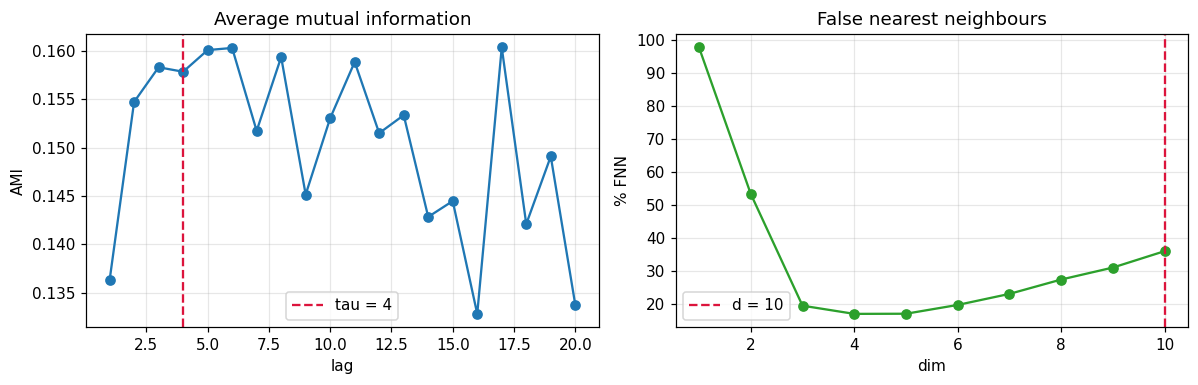

In [8]:
def average_mutual_information(
    series: np.ndarray, max_lag: int = 20, bins: int = 16
) -> np.ndarray:
    """Average Mutual Information vs lag."""
    out = []
    for lag in range(1, max_lag + 1):
        x, y = series[:-lag], series[lag:]
        contingency = np.histogram2d(x, y, bins=bins)[0]
        out.append(mutual_info_score(None, None, contingency=contingency))
    return np.asarray(out)


def find_optimal_tau(series: np.ndarray, max_lag: int = 20) -> Tuple[int, np.ndarray]:
    """First local minimum of AMI curve."""
    ami = average_mutual_information(series, max_lag)
    for i in range(1, len(ami) - 1):
        if ami[i] < ami[i - 1] and ami[i] < ami[i + 1]:
            return i + 1, ami
    return int(np.argmin(ami)) + 1, ami


def takens_embedding(series: np.ndarray, tau: int, dim: int) -> np.ndarray:
    """Delay-coordinate embedding into R^dim."""
    span = (dim - 1) * tau
    n_points = len(series) - span
    if n_points <= 0:
        raise ValueError("Series too short for requested tau / dimension.")
    idx = np.arange(n_points)[:, None] + np.arange(0, span + 1, tau)[None, :]
    return series[idx]


def false_nearest_neighbors(
    series: np.ndarray, tau: int, max_dim: int = 10,
    r_tol: float = 15.0, a_tol: float = 2.0,
) -> Tuple[int, List[float]]:
    """Kennel's FNN criterion for minimal embedding dimension."""
    n = len(series)
    spread = float(np.std(series))
    percentages: List[float] = []
    chosen = max_dim

    for dim in range(1, max_dim + 1):
        try:
            emb = takens_embedding(series, tau, dim)
        except ValueError:
            break
        if len(emb) < 10:
            break

        tree = cKDTree(emb)
        dist, idx = tree.query(emb, k=2)
        nn_dist, nn_idx = dist[:, 1], idx[:, 1]

        future_i = np.arange(len(emb)) + dim * tau
        future_j = nn_idx + dim * tau
        ok = (future_i < n) & (future_j < n) & (nn_dist > 1e-10)
        if ok.sum() == 0:
            break

        delta = np.abs(series[future_i[ok]] - series[future_j[ok]])
        ratio = delta / nn_dist[ok]
        total = np.sqrt(nn_dist[ok] ** 2 + delta ** 2)
        false = (ratio > r_tol) | (total / (spread + 1e-12) > a_tol)

        pct = float(false.mean() * 100.0)
        percentages.append(pct)
        if pct < 1.0 and dim > 1:
            chosen = dim
            break
        chosen = dim

    return chosen, percentages


# Estimate only on the pre-test boundary
primary_ret_col = f"{CFG.primary_ticker.replace('^', '')}_logret"
PRIMARY_RET_IDX = RETURN_COLS.index(primary_ret_col)

if CFG.split_mode == "walkforward":
    _first_test_year = DATES[0].year + CFG.train_years
    _takens_boundary = pd.Timestamp(f"{_first_test_year - 1}-12-31")
    fit_end = int((DATES <= _takens_boundary).sum())
    if fit_end < 100:
        fit_end = int(N_SAMPLES * CFG.holdout_train)
else:
    fit_end = int(N_SAMPLES * CFG.holdout_train)

param_series = panel[primary_ret_col].values[: DATA["decision_rows"][fit_end]]
TAU, ami_curve = find_optimal_tau(param_series, CFG.max_ami_lag)
EMBED_DIM, fnn_curve = false_nearest_neighbors(param_series, TAU, CFG.max_embed_dim)

print(f"Estimated on {len(param_series)} samples (through {panel.index[DATA['decision_rows'][fit_end]].date()})")
print(f"Optimal delay      tau = {TAU}")
print(f"Optimal dimension  d   = {EMBED_DIM}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(range(1, len(ami_curve) + 1), ami_curve, marker="o", color="#1f77b4")
axes[0].axvline(TAU, color="crimson", linestyle="--", label=f"tau = {TAU}")
axes[0].set_title("Average mutual information"); axes[0].set_xlabel("lag"); axes[0].set_ylabel("AMI"); axes[0].legend()

axes[1].plot(range(1, len(fnn_curve) + 1), fnn_curve, marker="o", color="#2ca02c")
axes[1].axvline(EMBED_DIM, color="crimson", linestyle="--", label=f"d = {EMBED_DIM}")
axes[1].set_title("False nearest neighbours"); axes[1].set_xlabel("dim"); axes[1].set_ylabel("% FNN"); axes[1].legend()

plt.tight_layout(); savefig("takens_parameters"); plt.show()


## 7. Point Clouds & Persistent Homology
Computes $H_0$ and $H_1$ persistent homology with Vietoris-Rips filtration across multivariate ($R^6$) and Takens attractor ($R^d$) geometries.


In [9]:
def build_point_cloud(
    returns_window: np.ndarray, mode: str, tau: int, dim: int, cfg: Config
) -> np.ndarray:
    """Construct point cloud for requested geometry."""
    if mode == "multivariate":
        return np.ascontiguousarray(returns_window)
    if mode == "takens":
        series = returns_window[:, PRIMARY_RET_IDX]
        max_dim = 1 + (len(series) - cfg.min_cloud_points) // max(tau, 1)
        eff_dim = int(max(2, min(dim, max_dim)))
        return takens_embedding(series, tau, eff_dim)
    raise ValueError(f"Unknown point cloud mode: {mode}")


def compute_diagram(point_cloud: np.ndarray, maxdim: int = 1) -> List[np.ndarray]:
    """Vietoris-Rips persistence diagrams with H0 and H1 guarantees."""
    dgms = ripser(point_cloud, maxdim=maxdim)["dgms"]
    while len(dgms) < maxdim + 1:
        dgms.append(np.zeros((0, 2)))
    return [np.asarray(d, dtype=np.float64) for d in dgms]


def config_hash(cfg: Config, tau: int, dim: int) -> str:
    """Deterministic hash for caching diagrams."""
    payload = {
        "tickers": cfg.all_tickers, "start": cfg.start_date, "end": cfg.end_date,
        "windows": cfg.tda_windows, "modes": cfg.point_cloud_modes,
        "tau": tau, "dim": dim, "seq_len": cfg.seq_len, "horizon": cfg.horizon,
    }
    raw = json.dumps(payload, sort_keys=True).encode()
    return hashlib.md5(raw).hexdigest()[:12]


def compute_all_diagrams(
    data: Dict[str, Any], cfg: Config, tau: int, dim: int
) -> Dict[Tuple[int, str], List[List[np.ndarray]]]:
    """Compute all diagram streams across scales and geometries."""
    returns = data["returns_matrix"]
    ends = data["ends"]
    store: Dict[Tuple[int, str], List[List[np.ndarray]]] = {}

    for window in cfg.tda_windows:
        for mode in cfg.point_cloud_modes:
            key = (window, mode)
            print(f"  W={window:<3} mode={mode:<13} ", end="", flush=True)
            diagrams: List[List[np.ndarray]] = []
            for i, e in enumerate(ends):
                cloud = build_point_cloud(returns[e - window:e], mode, tau, dim, cfg)
                diagrams.append(compute_diagram(cloud, maxdim=1))
                if (i + 1) % 1000 == 0:
                    print(".", end="", flush=True)
            store[key] = diagrams
            print(f" done ({len(diagrams)} diagrams)")
    return store


CACHE_KEY = config_hash(CFG, TAU, EMBED_DIM)
CACHE_PATH = os.path.join(CFG.cache_dir, f"diagrams_{CACHE_KEY}.npz")

if CFG.use_cache and os.path.exists(CACHE_PATH):
    print(f"Loading cached diagrams from {CACHE_PATH}")
    blob = np.load(CACHE_PATH, allow_pickle=True)
    DIAGRAMS = blob["diagrams"].item()
else:
    print("Computing persistence diagrams ...")
    DIAGRAMS = compute_all_diagrams(DATA, CFG, TAU, EMBED_DIM)
    if CFG.use_cache:
        np.savez_compressed(CACHE_PATH, diagrams=np.array(DIAGRAMS, dtype=object))
        print(f"Cached to {CACHE_PATH}")

print(f"\nDiagram streams ready: {list(DIAGRAMS.keys())}")


Computing persistence diagrams ...
  W=30  mode=multivariate  ..... done (5111 diagrams)
  W=30  mode=takens        ..... done (5111 diagrams)
  W=45  mode=multivariate  ..... done (5111 diagrams)
  W=45  mode=takens        ..... done (5111 diagrams)
  W=60  mode=multivariate  ..... done (5111 diagrams)
  W=60  mode=takens        ..... done (5111 diagrams)
Cached to ./cache/diagrams_001b5fb38f48.npz

Diagram streams ready: [(30, 'multivariate'), (30, 'takens'), (45, 'multivariate'), (45, 'takens'), (60, 'multivariate'), (60, 'takens')]


## 8. Topological Feature Vectorization
Transforms persistence diagrams into fixed-length numeric representations (Betti curves, entropy, landscapes, Wasserstein drift, persistence images) and applies expanding causal z-scoring.


In [10]:
def betti_curve(diagram: np.ndarray, n_bins: int) -> np.ndarray:
    """Betti numbers along filtration radii."""
    finite = diagram[np.isfinite(diagram[:, 1])]
    if len(finite) == 0:
        return np.zeros(n_bins)
    births, deaths = finite[:, 0], finite[:, 1]
    lo, hi = births.min(), deaths.max()
    if hi <= lo:
        hi = lo + 1.0
    radii = np.linspace(lo, hi, n_bins)
    return ((births[None, :] <= radii[:, None]) & (deaths[None, :] > radii[:, None])).sum(axis=1).astype(float)


def persistent_entropy(diagram: np.ndarray) -> float:
    """Lifespan distribution entropy."""
    finite = diagram[np.isfinite(diagram[:, 1])]
    if len(finite) == 0:
        return 0.0
    life = finite[:, 1] - finite[:, 0]
    life = life[life > 0]
    if len(life) == 0 or life.sum() <= 0:
        return 0.0
    p = life / life.sum()
    return float(-np.sum(p * np.log(p + 1e-12)))


def landscape_norms(diagram: np.ndarray, n_layers: int, resolution: int) -> np.ndarray:
    """L1 and L2 norms of persistence landscapes."""
    finite = diagram[np.isfinite(diagram[:, 1])]
    if len(finite) == 0:
        return np.zeros(n_layers * 2)
    births, deaths = finite[:, 0], finite[:, 1]
    mid = (births + deaths) / 2.0
    half = (deaths - births) / 2.0
    lo, hi = births.min(), deaths.max()
    if hi <= lo:
        return np.zeros(n_layers * 2)

    grid = np.linspace(lo, hi, resolution)
    tents = np.maximum(0.0, half[:, None] - np.abs(grid[None, :] - mid[:, None]))
    ordered = -np.sort(-tents, axis=0)

    layers = np.zeros((n_layers, resolution))
    take = min(n_layers, ordered.shape[0])
    layers[:take] = ordered[:take]

    dt = (hi - lo) / resolution
    norms = np.empty(n_layers * 2)
    norms[0::2] = np.abs(layers).sum(axis=1) * dt
    norms[1::2] = np.sqrt((layers ** 2).sum(axis=1) * dt)
    return norms


def top_k_by_persistence(diagram: np.ndarray, k: int) -> np.ndarray:
    finite = diagram[np.isfinite(diagram[:, 1])]
    if len(finite) <= k:
        return finite if len(finite) else np.zeros((0, 2))
    life = finite[:, 1] - finite[:, 0]
    return finite[np.argsort(-life)[:k]]


def wasserstein_drift(prev: Optional[List[np.ndarray]], curr: List[np.ndarray], k: int) -> np.ndarray:
    """1-Wasserstein distance between consecutive temporal windows."""
    if prev is None:
        return np.zeros(2)
    out = np.zeros(2)
    for dim in range(2):
        a = top_k_by_persistence(prev[dim], k)
        b = top_k_by_persistence(curr[dim], k)
        if len(a) == 0 and len(b) == 0:
            continue
        a = np.zeros((1, 2)) if len(a) == 0 else a
        b = np.zeros((1, 2)) if len(b) == 0 else b
        try:
            out[dim] = float(wasserstein(a, b))
        except Exception:
            out[dim] = 0.0
    return out


def fit_persistence_imager(diagrams: List[List[np.ndarray]], fit_end: int, cfg: Config) -> PersistenceImager:
    """Fit persistence image raster grid on training period H1 diagrams only."""
    pool = [d[1][np.isfinite(d[1][:, 1])] for d in diagrams[:fit_end]]
    pool = [p for p in pool if len(p) > 0]
    if not pool:
        return PersistenceImager(birth_range=(0.0, 1.0), pers_range=(0.0, 1.0), pixel_size=0.05)
    stacked = np.vstack(pool)
    births = stacked[:, 0]
    pers = stacked[:, 1] - stacked[:, 0]
    birth_range = (float(births.min()), float(births.max()) + 1e-6)
    pers_range = (float(pers.min()), float(pers.max()) + 1e-6)
    span = min(birth_range[1] - birth_range[0], pers_range[1] - pers_range[0])
    pixel = float(max(span / cfg.persistence_image_raw_bins, 1e-5))
    return PersistenceImager(birth_range=birth_range, pers_range=pers_range, pixel_size=pixel)


def persistence_image_vector(diagram: np.ndarray, imager: PersistenceImager, shape: Tuple[int, int]) -> np.ndarray:
    finite = diagram[np.isfinite(diagram[:, 1])]
    raw = np.asarray(imager.transform(finite) if len(finite) else np.zeros(imager.resolution), dtype=float)
    if raw.shape != shape:
        raw = zoom(raw, (shape[0] / raw.shape[0], shape[1] / raw.shape[1]), order=1)
    return raw.reshape(-1)


def vectorize_stream(
    diagrams: List[List[np.ndarray]], imager: Optional[PersistenceImager], cfg: Config
) -> Tuple[np.ndarray, List[str]]:
    rows: List[np.ndarray] = []
    families: List[str] = []
    prev: Optional[List[np.ndarray]] = None

    for idx, dgm in enumerate(diagrams):
        parts: List[np.ndarray] = []
        tags: List[str] = []

        for dim in (0, 1):
            parts.append(betti_curve(dgm[dim], cfg.n_betti_bins))
            tags += [f"betti_H{dim}"] * cfg.n_betti_bins
        for dim in (0, 1):
            parts.append(np.array([persistent_entropy(dgm[dim])]))
            tags += [f"entropy_H{dim}"]
        for dim in (0, 1):
            parts.append(landscape_norms(dgm[dim], cfg.n_landscape_layers, cfg.landscape_resolution))
            tags += [f"landscape_H{dim}"] * (cfg.n_landscape_layers * 2)

        parts.append(wasserstein_drift(prev, dgm, cfg.max_wasserstein_points))
        tags += ["wasserstein"] * 2

        if cfg.use_persistence_images and imager is not None:
            parts.append(persistence_image_vector(dgm[1], imager, cfg.persistence_image_shape))
            tags += ["pimage_H1"] * int(np.prod(cfg.persistence_image_shape))

        rows.append(np.concatenate(parts))
        if idx == 0:
            families = tags
        prev = dgm

    return np.asarray(rows, dtype=np.float64), families


def expanding_zscore(features: np.ndarray, min_periods: int, clip: float) -> np.ndarray:
    """Strictly causal expanding z-score standardisation."""
    n, d = features.shape
    counts = np.arange(1, n + 1, dtype=np.float64)[:, None]
    mean = np.cumsum(features, axis=0) / counts
    mean_sq = np.cumsum(features ** 2, axis=0) / counts

    prev_mean = np.vstack([np.zeros((1, d)), mean[:-1]])
    prev_mean_sq = np.vstack([np.zeros((1, d)), mean_sq[:-1]])
    prev_std = np.sqrt(np.maximum(prev_mean_sq - prev_mean ** 2, 0.0)) + 1e-9

    out = (features - prev_mean) / prev_std
    out[:min_periods] = 0.0
    return np.clip(np.nan_to_num(out), -clip, clip)


if CFG.split_mode == "walkforward":
    _pi_first_test = DATES[0].year + CFG.train_years
    _pi_boundary = pd.Timestamp(f"{_pi_first_test - 1}-12-31")
    PI_FIT_END = int((DATES <= _pi_boundary).sum())
    if PI_FIT_END < 100:
        PI_FIT_END = int(N_SAMPLES * CFG.holdout_train)
else:
    PI_FIT_END = int(N_SAMPLES * CFG.holdout_train)

blocks: List[np.ndarray] = []
feat_window: List[int] = []
feat_mode: List[str] = []
feat_family: List[str] = []
IMAGERS: Dict[Tuple[int, str], PersistenceImager] = {}

for window in CFG.tda_windows:
    for mode in CFG.point_cloud_modes:
        key = (window, mode)
        imager = (fit_persistence_imager(DIAGRAMS[key], PI_FIT_END, CFG) if CFG.use_persistence_images else None)
        IMAGERS[key] = imager
        matrix, families = vectorize_stream(DIAGRAMS[key], imager, CFG)
        blocks.append(matrix)
        feat_window += [window] * matrix.shape[1]
        feat_mode += [mode] * matrix.shape[1]
        feat_family += families
        print(f"  W={window:<3} {mode:<13} -> {matrix.shape[1]:4d} features")

TDA_RAW = np.concatenate(blocks, axis=1)
TDA_FEATURES = expanding_zscore(TDA_RAW, CFG.zscore_min_periods, CFG.zscore_clip)

FEAT_WINDOW = np.asarray(feat_window)
FEAT_MODE = np.asarray(feat_mode)
FEAT_FAMILY = np.asarray(feat_family)
TDA_NAMES = [f"W{w}|{m}|{f}" for w, m, f in zip(FEAT_WINDOW, FEAT_MODE, FEAT_FAMILY)]

print(f"\nTopological feature matrix: {TDA_FEATURES.shape}")


def select_tda(
    families: Optional[Sequence[str]] = None,
    windows: Optional[Sequence[int]] = None,
    modes: Optional[Sequence[str]] = None,
) -> np.ndarray:
    """Boolean selector mask over topological features."""
    mask = np.ones(TDA_FEATURES.shape[1], dtype=bool)
    if families is not None:
        mask &= np.isin(FEAT_FAMILY, list(families))
    if windows is not None:
        mask &= np.isin(FEAT_WINDOW, list(windows))
    if modes is not None:
        mask &= np.isin(FEAT_MODE, list(modes))
    return mask


  W=30  multivariate  ->  144 features
  W=30  takens        ->  144 features
  W=45  multivariate  ->  144 features
  W=45  takens        ->  144 features
  W=60  multivariate  ->  144 features
  W=60  takens        ->  144 features

Topological feature matrix: (5111, 864)


## 9. Crash Lead-Time Diagnostics
Evaluates whether unstandardized topological metrics exhibit leading peaks ahead of historical major drawdowns (2008 GFC, 2020 COVID, 2022 Rate Shock).


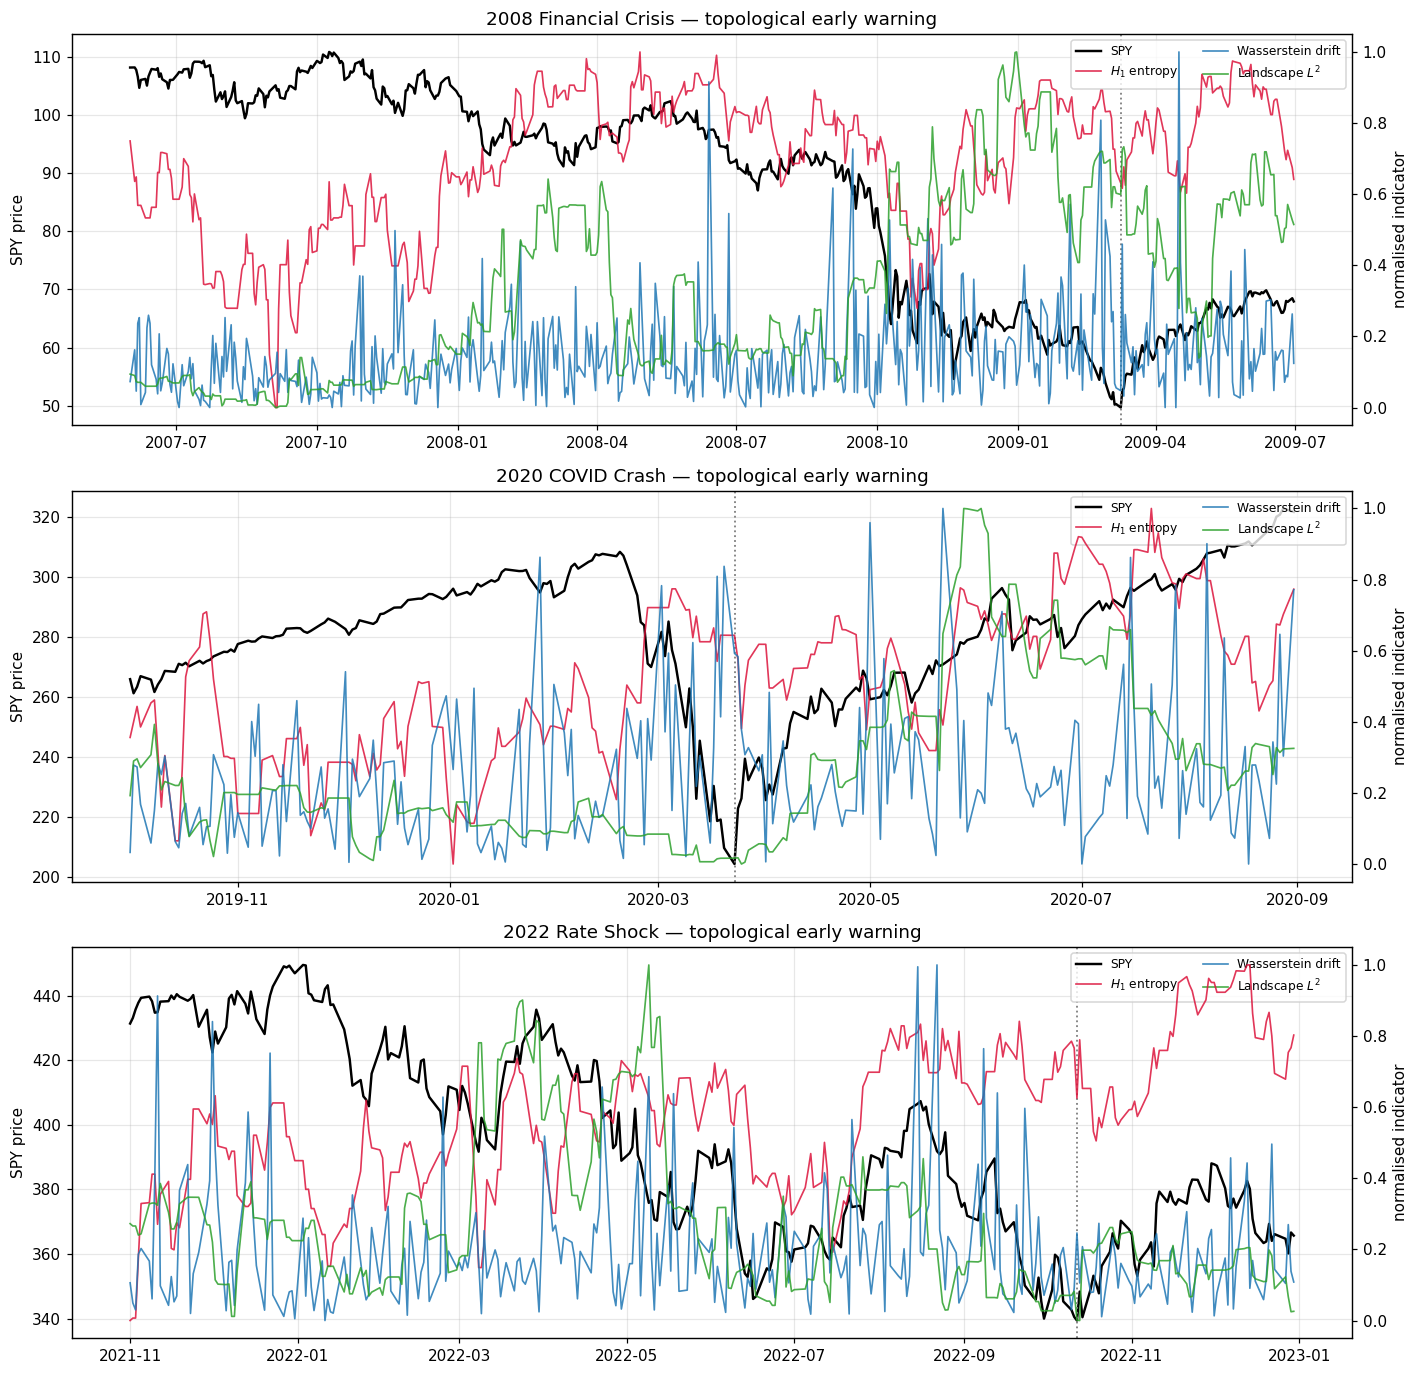


=== Indicator peak vs price trough (positive lead days = early warning) ===
               period         indicator indicator_peak price_trough  lead_days
2008 Financial Crisis       H_1 entropy     2008-04-29   2009-03-09        314
2008 Financial Crisis Wasserstein drift     2009-04-16   2009-03-09        -38
2008 Financial Crisis     Landscape L^2     2008-12-31   2009-03-09         68
     2020 COVID Crash       H_1 entropy     2020-07-21   2020-03-23       -120
     2020 COVID Crash Wasserstein drift     2020-05-22   2020-03-23        -60
     2020 COVID Crash     Landscape L^2     2020-06-02   2020-03-23        -71
      2022 Rate Shock       H_1 entropy     2022-12-13   2022-10-12        -62
      2022 Rate Shock Wasserstein drift     2022-08-22   2022-10-12         51
      2022 Rate Shock     Landscape L^2     2022-05-09   2022-10-12        156


In [11]:
CRASH_PERIODS = {
    "2008 Financial Crisis": ("2007-06-01", "2009-06-30"),
    "2020 COVID Crash": ("2019-10-01", "2020-08-31"),
    "2022 Rate Shock": ("2021-11-01", "2022-12-31"),
}

diag_window = max(CFG.tda_windows)
diag_mode = CFG.point_cloud_modes[0]

INDICATORS = {
    "$H_1$ entropy": select_tda(["entropy_H1"], [diag_window], [diag_mode]),
    "Wasserstein drift": select_tda(["wasserstein"], [diag_window], [diag_mode]),
    "Landscape $L^2$": select_tda(["landscape_H1"], [diag_window], [diag_mode]),
}

lead_rows = []
active = {
    name: (s, e) for name, (s, e) in CRASH_PERIODS.items()
    if ((DATES >= pd.Timestamp(s)) & (DATES <= pd.Timestamp(e))).sum() > 30
}

if active:
    fig, axes = plt.subplots(len(active), 1, figsize=(13, 4.2 * len(active)))
    axes = np.atleast_1d(axes)

    for ax, (name, (start, end)) in zip(axes, active.items()):
        mask = (DATES >= pd.Timestamp(start)) & (DATES <= pd.Timestamp(end))
        sub_dates = DATES[mask]
        sub_price = DATA["close"][mask]

        ax.plot(sub_dates, sub_price, color="black", lw=1.6, label=CFG.primary_ticker)
        ax.set_ylabel(f"{CFG.primary_ticker} price")
        ax.set_title(f"{name} — topological early warning")

        twin = ax.twinx()
        twin.grid(False)
        trough_date = sub_dates[int(np.argmin(sub_price))]

        for (label, col_mask), colour in zip(INDICATORS.items(), ["crimson", "#1f77b4", "#2ca02c"]):
            series = TDA_RAW[mask][:, col_mask].mean(axis=1)
            rng = series.max() - series.min()
            twin.plot(sub_dates, (series - series.min()) / (rng + 1e-12), lw=1.1, alpha=0.85, color=colour, label=label)

            peak_date = sub_dates[int(np.argmax(series))]
            lead_rows.append({
                "period": name, "indicator": label.replace("$", ""),
                "indicator_peak": peak_date.date(), "price_trough": trough_date.date(),
                "lead_days": (trough_date - peak_date).days,
            })

        twin.set_ylabel("normalised indicator")
        ax.axvline(trough_date, color="grey", ls=":", lw=1.2)
        handles = ax.get_legend_handles_labels()[0] + twin.get_legend_handles_labels()[0]
        labels_txt = ax.get_legend_handles_labels()[1] + twin.get_legend_handles_labels()[1]
        ax.legend(handles, labels_txt, loc="upper right", fontsize=8, ncol=2)

    plt.tight_layout(); savefig("crash_lead_time"); plt.show()
    print("\n=== Indicator peak vs price trough (positive lead days = early warning) ===")
    print(pd.DataFrame(lead_rows).to_string(index=False))


## 10. Walk-Forward Validation Protocol
Implements rolling 5-year train / 1-year test splits with an internal 20% validation buffer for leak-free early stopping.


In [12]:
Split = Tuple[np.ndarray, np.ndarray, np.ndarray]   # (train, val, test)


def walk_forward_splits(dates: pd.DatetimeIndex, cfg: Config) -> List[Split]:
    """Rolling calendar-year anchored train / test partitions."""
    splits: List[Split] = []
    first_year, last_year = dates.min().year, dates.max().year

    for test_year in range(first_year + cfg.train_years, last_year + 1, cfg.test_years):
        train_lo = pd.Timestamp(f"{test_year - cfg.train_years}-01-01")
        train_hi = pd.Timestamp(f"{test_year - 1}-12-31")
        test_lo = pd.Timestamp(f"{test_year}-01-01")
        test_hi = pd.Timestamp(f"{test_year + cfg.test_years - 1}-12-31")

        train_all = np.where((dates >= train_lo) & (dates <= train_hi))[0]
        test_idx = np.where((dates >= test_lo) & (dates <= test_hi))[0]
        if len(train_all) < 100 or len(test_idx) < 20:
            continue

        cut = int(len(train_all) * (1.0 - cfg.val_fraction))
        splits.append((train_all[:cut], train_all[cut:], test_idx))
    return splits


def holdout_splits(n_samples: int, cfg: Config) -> List[Split]:
    """Single chronological 70 / 15 / 15 partition."""
    train_cut = int(n_samples * cfg.holdout_train)
    val_cut = int(n_samples * cfg.holdout_val)
    return [(np.arange(0, train_cut), np.arange(train_cut, val_cut), np.arange(val_cut, n_samples))]


def get_splits(mode: str, dates: pd.DatetimeIndex, n_samples: int, cfg: Config) -> List[Split]:
    if mode == "walkforward":
        return walk_forward_splits(dates, cfg)
    if mode == "holdout":
        return holdout_splits(n_samples, cfg)
    raise ValueError(f"Unknown split mode: {mode}")


WF_SPLITS = walk_forward_splits(DATES, CFG)
HO_SPLITS = holdout_splits(N_SAMPLES, CFG)
SPLITS = get_splits(CFG.split_mode, DATES, N_SAMPLES, CFG)

print(f"Walk-forward folds : {len(WF_SPLITS)}")
for i, (tr, va, te) in enumerate(WF_SPLITS, start=1):
    print(f"  fold {i:2d}: train {len(tr):5d} | val {len(va):4d} | test {len(te):4d}  window {DATES[te[0]].date()} -> {DATES[te[-1]].date()}")


Walk-forward folds : 16
  fold  1: train   942 | val  236 | test  251  window 2010-01-04 -> 2010-12-31
  fold  2: train  1005 | val  252 | test  252  window 2011-01-03 -> 2011-12-30
  fold  3: train  1007 | val  252 | test  250  window 2012-01-03 -> 2012-12-31
  fold  4: train  1006 | val  252 | test  252  window 2013-01-02 -> 2013-12-31
  fold  5: train  1005 | val  252 | test  252  window 2014-01-02 -> 2014-12-31
  fold  6: train  1005 | val  252 | test  252  window 2015-01-02 -> 2015-12-31
  fold  7: train  1006 | val  252 | test  251  window 2016-01-04 -> 2016-12-30
  fold  8: train  1005 | val  252 | test  251  window 2017-01-03 -> 2017-12-29
  fold  9: train  1006 | val  252 | test  251  window 2018-01-02 -> 2018-12-31
  fold 10: train  1005 | val  252 | test  252  window 2019-01-02 -> 2019-12-31
  fold 11: train  1005 | val  252 | test  253  window 2020-01-02 -> 2020-12-31
  fold 12: train  1006 | val  252 | test  252  window 2021-01-04 -> 2021-12-31
  fold 13: train  1007 | val

## 11. Neural Architecture Zoo & Focal Loss
Defines unified PyTorch architectures (`BaselineLSTM`, `TDAOnlyMLP`, `GatedHybridLSTM`, `DualBranchCNNLSTM`) with GroupNorm and LayerNorm.


In [13]:
class TDADataset(Dataset):
    """Dataset binding sequential data, topological features, and target labels."""
    def __init__(self, x_seq: np.ndarray, x_tda: np.ndarray, y: np.ndarray, idx: np.ndarray):
        self.x_seq = torch.as_tensor(x_seq[idx], dtype=torch.float32)
        self.x_tda = torch.as_tensor(x_tda[idx], dtype=torch.float32)
        self.y = torch.as_tensor(y[idx], dtype=torch.long)

    def __len__(self) -> int:
        return len(self.y)

    def __getitem__(self, i: int):
        return self.x_seq[i], self.x_tda[i], self.y[i]


class FocalLoss(nn.Module):
    """Multi-class focal cross-entropy loss."""
    def __init__(self, alpha: Optional[torch.Tensor] = None, gamma: float = 2.0):
        super().__init__()
        self.register_buffer("alpha", alpha if alpha is not None else None)
        self.gamma = gamma

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        ce = F.cross_entropy(logits, targets, weight=self.alpha, reduction="none")
        if self.gamma == 0.0:
            return ce.mean()
        pt = torch.exp(-ce)
        return (((1.0 - pt) ** self.gamma) * ce).mean()


class BaselineLSTM(nn.Module):
    """Sequence-only baseline LSTM."""
    def __init__(self, n_features: int, tda_dim: int = 0, n_classes: int = 3, hidden: int = 64, dropout: float = 0.25):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden, batch_first=True)
        self.head = nn.Sequential(
            nn.Linear(hidden, 32), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(32, n_classes),
        )

    def forward(self, x_seq, x_tda=None):
        _, (h_n, _) = self.lstm(x_seq)
        return self.head(h_n[-1])


class TDAOnlyMLP(nn.Module):
    """Topology-only MLP without sequential time-series input."""
    def __init__(self, n_features: int, tda_dim: int, n_classes: int = 3, dropout: float = 0.25):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(tda_dim, 64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, 32), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(32, n_classes),
        )

    def forward(self, x_seq, x_tda):
        return self.net(x_tda)


class GatedHybridLSTM(nn.Module):
    """Recurrent sequence model adaptively fused with topological embeddings via learned gating."""
    def __init__(self, n_features: int, tda_dim: int, n_classes: int = 3, hidden: int = 64, tda_hidden: int = 32, dropout: float = 0.25):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden, batch_first=True)
        self.tda_encoder = nn.Sequential(
            nn.Linear(tda_dim, 64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, tda_hidden), nn.ReLU(),
        )
        fusion = min(hidden, tda_hidden)
        self.seq_proj = nn.Linear(hidden, fusion)
        self.tda_proj = nn.Linear(tda_hidden, fusion)
        self.gate = nn.Sequential(
            nn.Linear(fusion * 2, fusion), nn.ReLU(),
            nn.Linear(fusion, fusion), nn.Sigmoid(),
        )
        self.head = nn.Sequential(
            nn.Linear(fusion, 32), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(32, n_classes),
        )

    def forward(self, x_seq, x_tda, return_gate: bool = False):
        _, (h_n, _) = self.lstm(x_seq)
        seq_repr = self.seq_proj(h_n[-1])
        tda_repr = self.tda_proj(self.tda_encoder(x_tda))
        gate = self.gate(torch.cat([seq_repr, tda_repr], dim=-1))
        fused = gate * seq_repr + (1.0 - gate) * tda_repr
        logits = self.head(fused)
        return (logits, gate) if return_gate else logits


class DualBranchCNNLSTM(nn.Module):
    """Dual-branch CNN-LSTM with GroupNorm and LayerNorm."""
    def __init__(self, n_features: int, tda_dim: int, n_classes: int = 3, hidden: int = 64, dropout: float = 0.25):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(n_features, 64, kernel_size=3, padding=1),
            nn.GroupNorm(1, 64), nn.ReLU(), nn.Dropout(dropout),
            nn.Conv1d(64, 32, kernel_size=3, padding=1),
            nn.GroupNorm(1, 32), nn.ReLU(), nn.Dropout(dropout),
        )
        self.lstm = nn.LSTM(32, hidden, num_layers=2, batch_first=True, dropout=dropout)
        self.tda_encoder = nn.Sequential(
            nn.Linear(tda_dim, 64), nn.ReLU(), nn.LayerNorm(64), nn.Dropout(dropout),
            nn.Linear(64, 32), nn.ReLU(), nn.LayerNorm(32), nn.Dropout(dropout),
        )
        self.seq_proj = nn.Linear(hidden, 64)
        self.tda_proj = nn.Linear(32, 64)
        self.gate = nn.Sequential(nn.Linear(128, 64), nn.Sigmoid())
        self.head = nn.Sequential(
            nn.Linear(64, 32), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(32, n_classes),
        )

    def forward(self, x_seq, x_tda, return_gate: bool = False):
        h = self.conv(x_seq.permute(0, 2, 1)).permute(0, 2, 1)
        _, (h_n, _) = self.lstm(h)
        seq_repr = self.seq_proj(h_n[-1])
        tda_repr = self.tda_proj(self.tda_encoder(x_tda))
        gate = self.gate(torch.cat([seq_repr, tda_repr], dim=-1))
        fused = gate * seq_repr + (1.0 - gate) * tda_repr
        logits = self.head(fused)
        return (logits, gate) if return_gate else logits


MODEL_REGISTRY = {
    "BaselineLSTM": BaselineLSTM,
    "TDAOnlyMLP": TDAOnlyMLP,
    "GatedHybridLSTM": GatedHybridLSTM,
    "DualBranchCNNLSTM": DualBranchCNNLSTM,
}


## 12. Training Loop & Walk-Forward Runner
Standardized walk-forward neural training loop with fold-specific inverse-frequency class weights, gradient clipping, and plateau scheduling.


In [14]:
def class_weights_from(labels: np.ndarray, n_classes: int) -> np.ndarray:
    """Inverse class frequency weights from training labels only."""
    counts = np.bincount(labels, minlength=n_classes).astype(float)
    counts[counts == 0] = 1.0
    weights = len(labels) / (n_classes * counts)
    return weights / weights.mean()


def train_torch_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    cfg: Config,
    class_weights: Optional[np.ndarray] = None,
    epochs: Optional[int] = None,
    verbose: bool = False,
) -> Tuple[nn.Module, Dict[str, List[float]]]:
    """Optimization with AdamW, focal loss, plateau scheduling, and early stopping."""
    model = model.to(DEVICE)
    alpha = (torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)
             if class_weights is not None else None)
    criterion = FocalLoss(alpha=alpha, gamma=cfg.focal_gamma).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.learning_rate, weight_decay=cfg.weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=max(2, cfg.patience // 2)
    )

    history: Dict[str, List[float]] = {"train_loss": [], "val_loss": []}
    best_loss, best_state, wait = float("inf"), None, 0
    n_epochs = epochs if epochs is not None else cfg.epochs

    for epoch in range(n_epochs):
        model.train()
        train_losses = []
        for x_seq, x_tda, y in train_loader:
            x_seq, x_tda, y = x_seq.to(DEVICE), x_tda.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(x_seq, x_tda), y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for x_seq, x_tda, y in val_loader:
                x_seq, x_tda, y = x_seq.to(DEVICE), x_tda.to(DEVICE), y.to(DEVICE)
                val_losses.append(criterion(model(x_seq, x_tda), y).item())

        tr_loss = float(np.mean(train_losses)) if train_losses else float("nan")
        vl_loss = float(np.mean(val_losses)) if val_losses else float("nan")
        history["train_loss"].append(tr_loss)
        history["val_loss"].append(vl_loss)
        scheduler.step(vl_loss)

        if verbose and (epoch + 1) % 10 == 0:
            print(f"    epoch {epoch + 1:02d} | train {tr_loss:.4f} | val {vl_loss:.4f}")

        if vl_loss < best_loss - 1e-6:
            best_loss = vl_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= cfg.patience:
                if verbose:
                    print(f"    early stop at epoch {epoch + 1}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model.to(DEVICE), history


@torch.no_grad()
def predict_probs(
    model: nn.Module, loader: DataLoader, want_gate: bool = False
) -> Tuple[np.ndarray, np.ndarray, Optional[np.ndarray]]:
    """Generate out-of-sample predictions."""
    model.eval()
    probs, targets, gates = [], [], []
    supports_gate = want_gate and isinstance(model, (GatedHybridLSTM, DualBranchCNNLSTM))

    for x_seq, x_tda, y in loader:
        x_seq, x_tda = x_seq.to(DEVICE), x_tda.to(DEVICE)
        if supports_gate:
            logits, gate = model(x_seq, x_tda, return_gate=True)
            gates.append(gate.mean(dim=1).cpu().numpy())
        else:
            logits = model(x_seq, x_tda)
        probs.append(F.softmax(logits, dim=1).cpu().numpy())
        targets.append(y.numpy())

    gate_arr = np.concatenate(gates) if gates else None
    return np.concatenate(probs), np.concatenate(targets), gate_arr


def run_torch_experiment(
    model_name: str,
    x_seq: np.ndarray,
    x_tda: np.ndarray,
    labels: np.ndarray,
    splits: List[Split],
    cfg: Config,
    seed: Optional[int] = None,
    epochs: Optional[int] = None,
    verbose: bool = False,
) -> Dict[str, Any]:
    """Train across all walk-forward folds and concatenate out-of-sample evaluations."""
    seed = cfg.seed if seed is None else seed
    factory = MODEL_REGISTRY[model_name]

    probs_all, labels_all, idx_all, gates_all = [], [], [], []
    histories: List[Dict[str, List[float]]] = []

    for fold, (tr_idx, va_idx, te_idx) in enumerate(splits, start=1):
        seed_everything(seed + fold)

        loaders = [
            DataLoader(TDADataset(x_seq, x_tda, labels, idx),
                       batch_size=cfg.batch_size, shuffle=shuffle,
                       drop_last=shuffle and len(idx) > cfg.batch_size)
            for idx, shuffle in [(tr_idx, True), (va_idx, False), (te_idx, False)]
        ]
        train_loader, val_loader, test_loader = loaders

        model = factory(
            n_features=x_seq.shape[-1],
            tda_dim=x_tda.shape[-1],
            n_classes=cfg.n_classes,
            dropout=cfg.dropout,
        )
        weights = class_weights_from(labels[tr_idx], cfg.n_classes)
        model, history = train_torch_model(
            model, train_loader, val_loader, cfg,
            class_weights=weights, epochs=epochs, verbose=verbose,
        )

        probs, targets, gates = predict_probs(model, test_loader, want_gate=True)
        probs_all.append(probs)
        labels_all.append(targets)
        idx_all.append(te_idx)
        histories.append(history)
        if gates is not None:
            gates_all.append(gates)

    return {
        "name": model_name,
        "probs": np.concatenate(probs_all),
        "labels": np.concatenate(labels_all),
        "idx": np.concatenate(idx_all),
        "gates": np.concatenate(gates_all) if gates_all else None,
        "histories": histories,
    }


## 13. Evaluation Engine: Metrics, Matched Benchmarks & Deflated Sharpe
Comprehensive evaluation framework implementing statistical metrics, exposure-matched benchmarks, volatility-scaled benchmarks, and the Deflated Sharpe Ratio (Bailey & López de Prado, 2014).


In [15]:
def deflated_sharpe_ratio(
    strat_returns: np.ndarray,
    n_trials: int = 60,
    var_sharpes: float = 0.5,
    trading_days: int = 252,
) -> float:
    """Deflated Sharpe Ratio (Bailey & Lopez de Prado, 2014).

    Adjusts for multiple comparisons across tested architectures, feature representations,
    and threshold parameters, accounting for non-normality (skewness & kurtosis).
    """
    n = len(strat_returns)
    if n < 10 or np.std(strat_returns) == 0:
        return float("nan")

    mean = np.mean(strat_returns)
    std = np.std(strat_returns, ddof=1)
    if std <= 1e-12:
        return 0.0
    sr_daily = mean / std
    sr_ann = sr_daily * np.sqrt(trading_days)

    skew = float(stats.skew(strat_returns))
    kurt = float(stats.kurtosis(strat_returns, fisher=False))  # Pearson kurtosis

    # Estimated variance of the annualized Sharpe ratio
    sr_var = (1.0 - skew * sr_daily + ((kurt - 1.0) / 4.0) * (sr_daily ** 2)) / n * trading_days
    sr_std = np.sqrt(max(sr_var, 1e-12))

    # Expected maximum Sharpe ratio under the null hypothesis of n_trials
    euler_mascheroni = 0.57721566490153286
    if n_trials <= 1:
        sr_0 = 0.0
    else:
        z1 = stats.norm.ppf(1.0 - 1.0 / n_trials)
        z2 = stats.norm.ppf(1.0 - 1.0 / (n_trials * np.e))
        sr_0 = np.sqrt(var_sharpes) * ((1.0 - euler_mascheroni) * z1 + euler_mascheroni * z2)

    dsr = stats.norm.cdf((sr_ann - sr_0) / sr_std)
    return float(dsr)


def benjamini_hochberg(p_values: Sequence[float], alpha: float = 0.05) -> Tuple[np.ndarray, np.ndarray]:
    """Benjamini-Hochberg False Discovery Rate (FDR) adjustment."""
    p_arr = np.asarray(p_values, dtype=float)
    valid_mask = np.isfinite(p_arr)
    adj_p = np.full_like(p_arr, np.nan, dtype=float)
    if not np.any(valid_mask):
        return adj_p, np.zeros_like(p_arr, dtype=bool)

    valid_p = p_arr[valid_mask]
    n = len(valid_p)
    order = np.argsort(valid_p)
    ranked_p = valid_p[order]

    factors = n / np.arange(1, n + 1)
    p_adj_sorted = ranked_p * factors
    p_adj_sorted = np.minimum.accumulate(p_adj_sorted[::-1])[::-1]
    p_adj_sorted = np.clip(p_adj_sorted, 0.0, 1.0)

    orig_adj = np.empty_like(valid_p)
    orig_adj[order] = p_adj_sorted
    adj_p[valid_mask] = orig_adj
    sig = adj_p <= alpha
    return adj_p, sig


def classification_metrics(y_true: np.ndarray, probs: np.ndarray, n_classes: int) -> Dict[str, float]:
    """Classification metrics with chance baseline reference."""
    preds = probs.argmax(axis=1)
    out = {
        "accuracy": accuracy_score(y_true, preds),
        "balanced_accuracy": balanced_accuracy_score(y_true, preds),
        "precision": precision_score(y_true, preds, average="macro", zero_division=0),
        "recall": recall_score(y_true, preds, average="macro", zero_division=0),
        "f1": f1_score(y_true, preds, average="macro", zero_division=0),
        "mcc": matthews_corrcoef(y_true, preds),
        "chance_baseline": 1.0 / n_classes,
    }
    try:
        out["roc_auc"] = (
            roc_auc_score(y_true, probs[:, 1]) if n_classes == 2
            else roc_auc_score(y_true, probs, multi_class="ovr", average="macro")
        )
    except Exception:
        out["roc_auc"] = float("nan")
    try:
        out["log_loss"] = log_loss(y_true, probs, labels=list(range(n_classes)))
    except Exception:
        out["log_loss"] = float("nan")
    return {k: float(v) for k, v in out.items()}


def positions_from_probs(probs: np.ndarray, cfg: Config) -> np.ndarray:
    """Map class probabilities onto a target position in {-1, 0, +1}."""
    if cfg.n_classes == 3:
        if cfg.signal_mode == "argmax":
            winner = probs.argmax(axis=1)
            return np.where(winner == 2, 1.0, np.where(winner == 0, -1.0, 0.0))
        p_short, p_long = probs[:, 0], probs[:, 2]
        long_leg = (p_long > cfg.prob_floor) & (p_long > p_short + cfg.prob_margin)
        short_leg = (p_short > cfg.prob_floor) & (p_short > p_long + cfg.prob_margin)
        return np.where(long_leg, 1.0, np.where(short_leg, -1.0, 0.0))
    if cfg.signal_mode == "argmax":
        return probs.argmax(axis=1).astype(float)
    return (probs[:, 1] > cfg.binary_threshold).astype(float)


def backtest(
    probs: np.ndarray, realized: np.ndarray, cfg: Config, cost_bps: float
) -> Dict[str, Any]:
    """Systematic backtest with matched and volatility-scaled benchmarks."""
    positions = positions_from_probs(probs, cfg)
    turnover = np.abs(np.diff(np.concatenate([[0.0], positions])))
    costs = turnover * (cost_bps / 10_000.0)
    strat = positions * realized - costs

    # Benchmark profiles
    # 1. Unadjusted 100% Buy & Hold
    bench_100 = realized
    # 2. Exposure-matched Benchmark: holds SPY exactly on the days the model is in-market
    bench_matched = np.sign(np.abs(positions)) * realized
    # 3. Volatility-scaled Benchmark: scales SPY returns to match realized strategy volatility
    strat_vol = strat.std() + 1e-12
    spy_vol = realized.std() + 1e-12
    bench_vol_scaled = (strat_vol / spy_vol) * realized

    equity = np.exp(np.cumsum(strat))
    peak = np.maximum.accumulate(equity)
    drawdown = equity / peak - 1.0

    mean, sd = strat.mean(), strat.std() + 1e-12
    downside = strat[strat < 0]
    downside_sd = downside.std() + 1e-12 if len(downside) else 1e-12
    annual = float(np.exp(mean * cfg.trading_days) - 1.0)
    mdd = float(drawdown.min())
    active = strat[positions != 0]
    years = max(len(positions) / cfg.trading_days, 1e-9)

    dsr = deflated_sharpe_ratio(strat, n_trials=cfg.n_total_trials_dsr, trading_days=cfg.trading_days)

    return {
        "metrics": {
            "annual_return": annual,
            "sharpe": float(mean / sd * np.sqrt(cfg.trading_days)),
            "deflated_sharpe_ratio": float(dsr),
            "sortino": float(mean / downside_sd * np.sqrt(cfg.trading_days)),
            "max_drawdown": mdd,
            "calmar": float(annual / abs(mdd)) if abs(mdd) > 1e-12 else float("nan"),
            "cumulative_return": float(equity[-1] - 1.0),
            "benchmark_return": float(np.exp(np.sum(bench_100)) - 1.0),
            "benchmark_matched_return": float(np.exp(np.sum(bench_matched)) - 1.0),
            "benchmark_matched_sharpe": float(bench_matched.mean() / (bench_matched.std() + 1e-12) * np.sqrt(cfg.trading_days)),
            "benchmark_vol_scaled_return": float(np.exp(np.sum(bench_vol_scaled)) - 1.0),
            "win_rate": float((active > 0).mean()) if len(active) else 0.0,
            "exposure": float((positions != 0).mean()),
            "turnover_py": float(turnover.sum() / years),
            "n_trades": int((turnover > 0).sum()),
        },
        "strategy_returns": strat,
        "positions": positions,
        "equity": equity - 1.0,
        "drawdown": drawdown,
        "bench_matched_returns": bench_matched,
        "bench_vol_scaled_returns": bench_vol_scaled,
    }


def evaluate_run(
    run: Dict[str, Any], cfg: Config, cost_bps: Optional[float] = None
) -> Dict[str, float]:
    """Combined classification and financial evaluation for a completed run."""
    cost = cfg.headline_cost_bps if cost_bps is None else cost_bps
    realized = FORWARD_RETURNS[run["idx"]]
    result = backtest(run["probs"], realized, cfg, cost)
    merged = classification_metrics(run["labels"], run["probs"], cfg.n_classes)
    merged.update(result["metrics"])
    merged["cost_bps"] = cost
    return merged


CLASSIFICATION_KEYS = ["accuracy", "balanced_accuracy", "chance_baseline", "precision", "recall", "f1", "roc_auc", "mcc", "log_loss"]
FINANCIAL_KEYS = ["annual_return", "sharpe", "deflated_sharpe_ratio", "sortino", "max_drawdown", "cumulative_return",
                  "benchmark_matched_return", "exposure", "n_trades"]
print("Evaluation engine initialized with Deflated Sharpe Ratio and matched benchmark calculations.")


Evaluation engine initialized with Deflated Sharpe Ratio and matched benchmark calculations.


## 14. Model A — TDA-LightGBM & SHAP Attribution
Gradient-boosted decision trees trained on concatenated tabular and topological features, with SHAP attribution analyzing the global importance of TDA descriptors.


In [16]:
import lightgbm as lgb

X_GBDT = np.concatenate([X_TAB, TDA_FEATURES.astype(np.float32)], axis=1)
GBDT_NAMES = list(FEATURE_COLS) + TDA_NAMES
print(f"Gradient-boosting feature matrix: {X_GBDT.shape}")


def train_lightgbm(X_tr, y_tr, X_va, y_va, cfg: Config):
    params = {
        "objective": "multiclass" if cfg.n_classes > 2 else "binary",
        "metric": "multi_logloss" if cfg.n_classes > 2 else "binary_logloss",
        "boosting_type": "gbdt", "num_leaves": 63, "learning_rate": 0.05,
        "feature_fraction": 0.8, "bagging_fraction": 0.8, "bagging_freq": 5,
        "min_data_in_leaf": 40, "lambda_l2": 1.0, "verbose": -1,
        "seed": cfg.seed, "n_jobs": -1,
    }
    if cfg.n_classes > 2:
        params["num_class"] = cfg.n_classes

    dtrain = lgb.Dataset(X_tr, label=y_tr)
    dvalid = lgb.Dataset(X_va, label=y_va, reference=dtrain)
    return lgb.train(
        params, dtrain, num_boost_round=1000, valid_sets=[dvalid],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)],
    )


def run_lightgbm_experiment(X, labels, splits, cfg: Config) -> Dict[str, Any]:
    probs_all, labels_all, idx_all = [], [], []
    booster = None
    for fold, (tr_idx, va_idx, te_idx) in enumerate(splits, start=1):
        booster = train_lightgbm(X[tr_idx], labels[tr_idx], X[va_idx], labels[va_idx], cfg)
        probs = booster.predict(X[te_idx], num_iteration=booster.best_iteration)
        probs = np.asarray(probs)
        if probs.ndim == 1:
            probs = np.column_stack([1.0 - probs, probs])
        probs_all.append(probs)
        labels_all.append(labels[te_idx])
        idx_all.append(te_idx)

    return {
        "name": "TDA-LightGBM", "probs": np.concatenate(probs_all),
        "labels": np.concatenate(labels_all), "idx": np.concatenate(idx_all),
        "gates": None, "histories": [], "booster": booster,
    }


print("\nTraining TDA-LightGBM ...")
seed_everything(CFG.seed)
RUN_LGB = run_lightgbm_experiment(X_GBDT, LABELS, SPLITS, CFG)

lgb_metrics = evaluate_run(RUN_LGB, CFG)
print(f"\nBalanced accuracy : {lgb_metrics['balanced_accuracy']:.4f} (chance = {CFG.chance_baseline:.1%})")
print(f"Macro F1          : {lgb_metrics['f1']:.4f}")
print(f"MCC               : {lgb_metrics['mcc']:.4f}")
print(f"Sharpe            : {lgb_metrics['sharpe']:.4f} (DSR = {lgb_metrics['deflated_sharpe_ratio']:.4f})")


Gradient-boosting feature matrix: (5111, 918)

Training TDA-LightGBM ...

Balanced accuracy : 0.3575 (chance = 33.3%)
Macro F1          : 0.2879
MCC               : 0.0689
Sharpe            : -0.0263 (DSR = 0.0000)


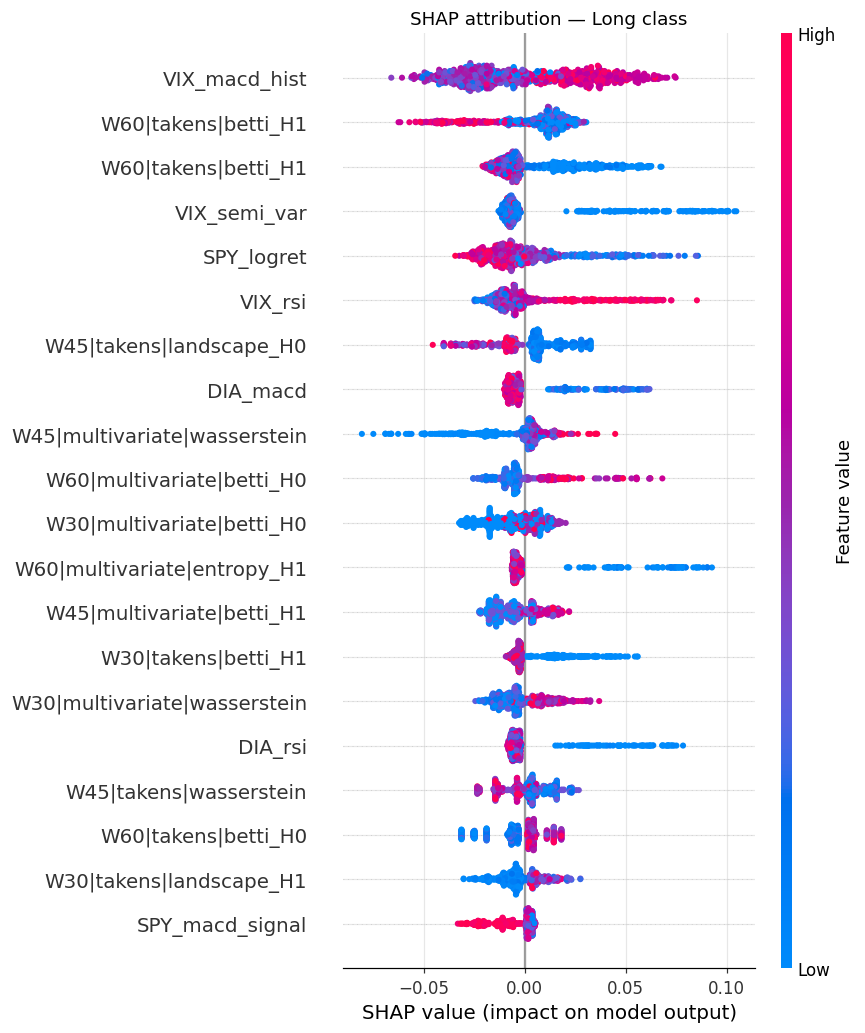

Share of mean |SHAP| carried by topological features: 73.7%


In [17]:
try:
    import shap
    booster = RUN_LGB["booster"]
    sample_idx = RUN_LGB["idx"][-800:]
    sample = X_GBDT[sample_idx]

    explainer = shap.TreeExplainer(booster)
    shap_values = explainer.shap_values(sample)

    if isinstance(shap_values, list):
        target_class = CFG.n_classes - 1
        values = shap_values[min(target_class, len(shap_values) - 1)]
    elif np.ndim(shap_values) == 3:
        values = shap_values[..., -1]
    else:
        values = shap_values

    plt.figure(figsize=(9, 7))
    shap.summary_plot(values, sample, feature_names=GBDT_NAMES, max_display=20, show=False)
    plt.title(f"SHAP attribution — {LABEL_NAMES[CFG.label_mode][-1]} class")
    plt.tight_layout(); savefig("shap_summary"); plt.show()

    magnitude = np.abs(values).mean(axis=0)
    is_tda = np.array([name in set(TDA_NAMES) for name in GBDT_NAMES])
    share = magnitude[is_tda].sum() / (magnitude.sum() + 1e-12)
    print(f"Share of mean |SHAP| carried by topological features: {share:.1%}")
except ImportError:
    print("shap is not installed; skipping attribution.")


## 15. Models B–E — Neural Architectures
Executes identical walk-forward training across the neural model suite (`BaselineLSTM`, `TDAOnlyMLP`, `GatedHybridLSTM`, `DualBranchCNNLSTM`).


In [18]:
NEURAL_MODELS = ["BaselineLSTM", "TDAOnlyMLP", "GatedHybridLSTM", "DualBranchCNNLSTM"]
RUNS: Dict[str, Dict[str, Any]] = {"TDA-LightGBM": RUN_LGB}

for model_name in NEURAL_MODELS:
    print(f"\nTraining {model_name} ...")
    RUNS[model_name] = run_torch_experiment(
        model_name, X_SEQ, TDA_FEATURES.astype(np.float32),
        LABELS, SPLITS, CFG, verbose=True,
    )
    m = evaluate_run(RUNS[model_name], CFG)
    print(f"  balanced accuracy {m['balanced_accuracy']:.4f} (chance {CFG.chance_baseline:.1%}) | "
          f"macro F1 {m['f1']:.4f} | MCC {m['mcc']:.4f} | Sharpe {m['sharpe']:.4f} (DSR {m['deflated_sharpe_ratio']:.3f})")

print(f"\nCompleted walk-forward evaluation of {len(RUNS)} models.")



Training BaselineLSTM ...
    epoch 10 | train 0.4407 | val 0.4492
    early stop at epoch 15
    epoch 10 | train 0.4317 | val 0.4457
    early stop at epoch 10
    epoch 10 | train 0.4237 | val 0.4594
    early stop at epoch 16
    epoch 10 | train 0.4338 | val 0.4569
    early stop at epoch 10
    epoch 10 | train 0.4192 | val 0.4392
    early stop at epoch 18
    epoch 10 | train 0.4197 | val 0.4452
    early stop at epoch 13
    epoch 10 | train 0.4265 | val 0.4533
    early stop at epoch 14
    epoch 10 | train 0.4277 | val 0.4462
    early stop at epoch 15
    epoch 10 | train 0.4245 | val 0.4209
    early stop at epoch 16
    epoch 10 | train 0.4035 | val 0.4501
    early stop at epoch 13
    epoch 10 | train 0.4059 | val 0.4208
    early stop at epoch 12
    epoch 10 | train 0.3934 | val 0.4386
    early stop at epoch 16
    epoch 10 | train 0.4017 | val 0.4312
    early stop at epoch 15
    epoch 10 | train 0.4120 | val 0.4702
    early stop at epoch 13
    epoch 10 | train 

## 16. Head-to-Head Comparison & Headline Framing
Calibrated performance reporting prioritizing classification rigor (Balanced Accuracy vs chance baseline, MCC) and reporting financial metrics with active exposure and trade count context.


In [19]:
rows = []
for name, run in RUNS.items():
    metrics = evaluate_run(run, CFG)
    metrics["model"] = name
    rows.append(metrics)

RESULTS = pd.DataFrame(rows).set_index("model")
buy_hold = RESULTS["benchmark_return"].iloc[0]

print("=" * 80)
print(f"OUT-OF-SAMPLE HEAD-TO-HEAD RESULTS ({CFG.split_mode}, {CFG.headline_cost_bps} bps)")
print("=" * 80)
print(f"Theoretical Chance Baseline: {CFG.chance_baseline:.1%}\n")

print("--- 1. Primary Classification Performance ---")
print(RESULTS[["balanced_accuracy", "chance_baseline", "mcc", "f1", "precision", "recall", "roc_auc", "log_loss"]].round(4).to_string())

print("\n--- 2. Financial Backtest & Risk Profiles ---")
print(RESULTS[["annual_return", "sharpe", "deflated_sharpe_ratio", "sortino", "max_drawdown",
               "cumulative_return", "benchmark_matched_return", "exposure", "n_trades"]].round(4).to_string())

best_bal_acc = RESULTS["balanced_accuracy"].idxmax()
best_mcc = RESULTS["mcc"].idxmax()
best_sharpe = RESULTS["sharpe"].idxmax()

print("\n" + "=" * 80)
print("HEADLINE SUMMARY:")
print(f"• Classification Leader: {best_bal_acc} (Balanced Accuracy = {RESULTS.loc[best_bal_acc, 'balanced_accuracy']:.4f} vs chance {CFG.chance_baseline:.1%}, MCC = {RESULTS.loc[best_mcc, 'mcc']:.4f})")
print(f"• Backtest Leader      : {best_sharpe} (Sharpe = {RESULTS.loc[best_sharpe, 'sharpe']:.2f}, DSR = {RESULTS.loc[best_sharpe, 'deflated_sharpe_ratio']:.3f}, but only {RESULTS.loc[best_sharpe, 'exposure']:.1%} exposure / {RESULTS.loc[best_sharpe, 'n_trades']} trades)")
print("=" * 80)

# Check for idle models
idle = RESULTS.index[RESULTS["exposure"] < 0.01].tolist()
if idle:
    print("\nNOTE: The following models never opened a trade under the threshold rules:")
    for name in idle:
        print(f"  - {name}: peak probability remained below entry floor ({CFG.prob_floor})")


OUT-OF-SAMPLE HEAD-TO-HEAD RESULTS (walkforward, 1.0 bps)
Theoretical Chance Baseline: 33.3%

--- 1. Primary Classification Performance ---
                   balanced_accuracy  chance_baseline     mcc      f1  precision  recall  roc_auc  log_loss
model                                                                                                      
TDA-LightGBM                  0.3575           0.3333  0.0689  0.2879     0.3800  0.3575   0.5428    1.0702
BaselineLSTM                  0.3502           0.3333  0.0346  0.2926     0.3809  0.3502   0.5581    1.1131
TDAOnlyMLP                    0.3404           0.3333  0.0140  0.2705     0.3540  0.3404   0.5034    1.1308
GatedHybridLSTM               0.3376           0.3333  0.0122  0.2485     0.3783  0.3376   0.5452    1.1214
DualBranchCNNLSTM             0.3418           0.3333  0.0161  0.2783     0.3585  0.3418   0.5214    1.1259

--- 2. Financial Backtest & Risk Profiles ---
                   annual_return  sharpe  deflated_sharpe

=== Transaction-Cost Sensitivity (Sharpe vs bps) ===

model     BaselineLSTM  DualBranchCNNLSTM  GatedHybridLSTM  TDA-LightGBM  TDAOnlyMLP
cost_bps                                                                            
0.0             -0.237              0.196           -0.303        -0.002      -0.098
1.0             -0.243              0.180           -0.328        -0.026      -0.118
5.0             -0.271              0.117           -0.427        -0.125      -0.195
10.0            -0.304              0.037           -0.549        -0.248      -0.291
20.0            -0.368             -0.123           -0.785        -0.486      -0.479


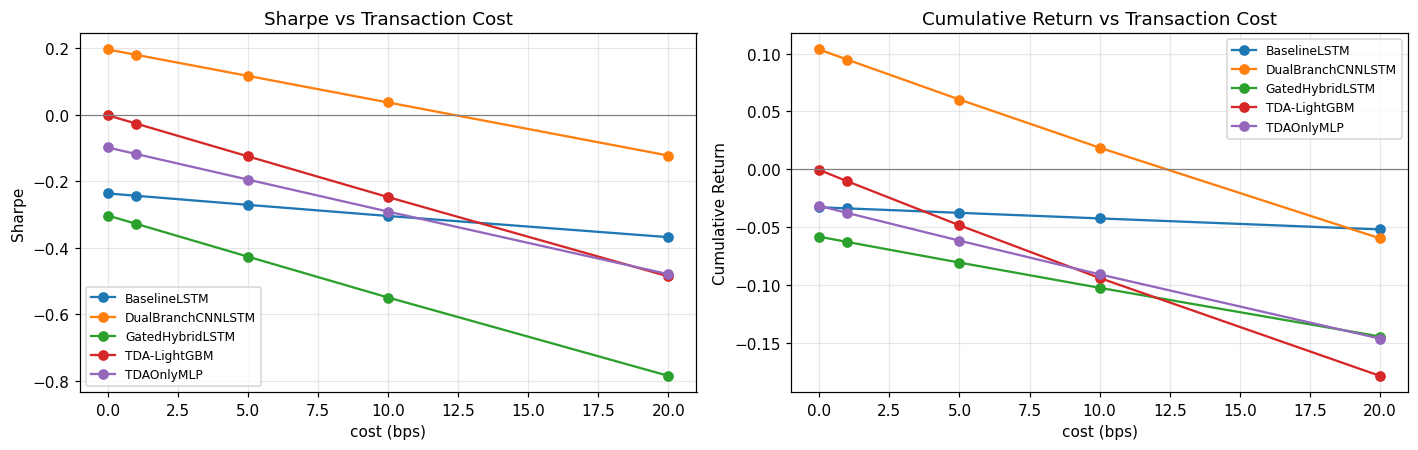

In [20]:
# Transaction cost sensitivity sweep
cost_rows = []
for name, run in RUNS.items():
    for cost in CFG.cost_grid_bps:
        m = evaluate_run(run, CFG, cost_bps=cost)
        cost_rows.append({
            "model": name, "cost_bps": cost, "sharpe": m["sharpe"],
            "deflated_sharpe_ratio": m["deflated_sharpe_ratio"],
            "cumulative_return": m["cumulative_return"],
            "max_drawdown": m["max_drawdown"], "n_trades": m["n_trades"],
        })

COST_DF = pd.DataFrame(cost_rows)
print("=== Transaction-Cost Sensitivity (Sharpe vs bps) ===\n")
print(COST_DF.pivot(index="cost_bps", columns="model", values="sharpe").round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for name, grp in COST_DF.groupby("model"):
    axes[0].plot(grp["cost_bps"], grp["sharpe"], marker="o", label=name)
    axes[1].plot(grp["cost_bps"], grp["cumulative_return"], marker="o", label=name)

axes[0].axhline(0, color="grey", lw=0.8); axes[0].set_xlabel("cost (bps)"); axes[0].set_ylabel("Sharpe")
axes[0].set_title("Sharpe vs Transaction Cost"); axes[0].legend(fontsize=8)
axes[1].axhline(0, color="grey", lw=0.8); axes[1].set_xlabel("cost (bps)"); axes[1].set_ylabel("Cumulative Return")
axes[1].set_title("Cumulative Return vs Transaction Cost"); axes[1].legend(fontsize=8)

plt.tight_layout(); savefig("cost_sensitivity"); plt.show()


## 17. Ablation Study
Isolates the marginal performance contribution of individual topological feature families and point cloud geometries under identical training budgets.


In [21]:
ZERO_TDA = np.zeros((N_SAMPLES, 1), dtype=np.float32)
largest = max(CFG.tda_windows)
primary_mode = CFG.point_cloud_modes[0]


def tda_subset(**kwargs) -> np.ndarray:
    mask = select_tda(**kwargs)
    return TDA_FEATURES[:, mask].astype(np.float32)


ABLATIONS: Dict[str, Tuple[str, np.ndarray]] = {
    "Sequence only (no TDA)": ("BaselineLSTM", ZERO_TDA),
    "TDA only (no sequence)": ("TDAOnlyMLP", TDA_FEATURES.astype(np.float32)),
    "+ H0 entropy": ("GatedHybridLSTM", tda_subset(families=["entropy_H0"])),
    "+ H1 entropy": ("GatedHybridLSTM", tda_subset(families=["entropy_H1"])),
    "+ Betti curves": ("GatedHybridLSTM", tda_subset(families=["betti_H0", "betti_H1"])),
    "+ Landscapes": ("GatedHybridLSTM", tda_subset(families=["landscape_H0", "landscape_H1"])),
    "+ Wasserstein drift": ("GatedHybridLSTM", tda_subset(families=["wasserstein"])),
    "+ Persistence images": ("GatedHybridLSTM", tda_subset(families=["pimage_H1"])),
    f"+ All TDA, single scale W={largest}": ("GatedHybridLSTM", tda_subset(windows=[largest], modes=[primary_mode])),
    "+ All TDA, multi-scale": ("GatedHybridLSTM", tda_subset(modes=[primary_mode])),
    "+ All TDA, multi-scale + Takens": ("GatedHybridLSTM", TDA_FEATURES.astype(np.float32)),
    "Full model (CNN-LSTM)": ("DualBranchCNNLSTM", TDA_FEATURES.astype(np.float32)),
}

if not CFG.use_persistence_images:
    ABLATIONS.pop("+ Persistence images", None)

ablation_rows = []
for label, (architecture, tda_input) in ABLATIONS.items():
    if tda_input.shape[1] == 0:
        continue
    print(f"Running ablation: {label} [{architecture}, tda_dim={tda_input.shape[1]}] ...")
    run = run_torch_experiment(architecture, X_SEQ, tda_input, LABELS, SPLITS, CFG, verbose=False)
    metrics = evaluate_run(run, CFG)
    metrics["configuration"] = label
    metrics["architecture"] = architecture
    metrics["tda_dim"] = tda_input.shape[1]
    ablation_rows.append(metrics)

ABLATION_DF = pd.DataFrame(ablation_rows).set_index("configuration")
print("\n=== Ablation Study Results ===\n")
print(ABLATION_DF[["architecture", "tda_dim", "balanced_accuracy", "f1", "mcc", "sharpe", "deflated_sharpe_ratio", "cumulative_return", "exposure"]].round(4).to_string())


Running ablation: Sequence only (no TDA) [BaselineLSTM, tda_dim=1] ...
Running ablation: TDA only (no sequence) [TDAOnlyMLP, tda_dim=864] ...
Running ablation: + H0 entropy [GatedHybridLSTM, tda_dim=6] ...
Running ablation: + H1 entropy [GatedHybridLSTM, tda_dim=6] ...
Running ablation: + Betti curves [GatedHybridLSTM, tda_dim=120] ...
Running ablation: + Landscapes [GatedHybridLSTM, tda_dim=120] ...
Running ablation: + Wasserstein drift [GatedHybridLSTM, tda_dim=12] ...
Running ablation: + Persistence images [GatedHybridLSTM, tda_dim=600] ...
Running ablation: + All TDA, single scale W=60 [GatedHybridLSTM, tda_dim=144] ...
Running ablation: + All TDA, multi-scale [GatedHybridLSTM, tda_dim=432] ...
Running ablation: + All TDA, multi-scale + Takens [GatedHybridLSTM, tda_dim=864] ...
Running ablation: Full model (CNN-LSTM) [DualBranchCNNLSTM, tda_dim=864] ...

=== Ablation Study Results ===

                                      architecture  tda_dim  balanced_accuracy      f1     mcc  s

## 18. Multi-Seed Stability, Hardened Bootstrap CI & Significance Testing
Multi-seed stability analysis across 8 random seeds with hardened bootstrap confidence intervals (guarding against $N < 6$ small sample artifacts) and Benjamini-Hochberg FDR correction.


In [22]:
STABILITY_MODELS = ["BaselineLSTM", "GatedHybridLSTM", "DualBranchCNNLSTM"]
stability_rows = []

print(f"Running multi-seed stability across {len(CFG.stability_seeds)} seeds ...")
for seed in CFG.stability_seeds:
    for model_name in STABILITY_MODELS:
        run = run_torch_experiment(
            model_name, X_SEQ, TDA_FEATURES.astype(np.float32),
            LABELS, SPLITS, CFG, seed=seed, verbose=False,
        )
        metrics = evaluate_run(run, CFG)
        metrics["model"] = model_name
        metrics["seed"] = seed
        stability_rows.append(metrics)
    print(f"  seed {seed} complete")

STABILITY_DF = pd.DataFrame(stability_rows)

SUMMARY_KEYS = ["balanced_accuracy", "f1", "roc_auc", "mcc", "sharpe", "deflated_sharpe_ratio", "annual_return", "max_drawdown", "exposure"]
summary = STABILITY_DF.groupby("model")[SUMMARY_KEYS].agg(["mean", "std"])
print(f"\n=== Multi-Seed Stability ({len(CFG.stability_seeds)} seeds: mean / std) ===\n")
print(summary.round(4).to_string())


Running multi-seed stability across 8 seeds ...
  seed 13 complete
  seed 42 complete
  seed 101 complete
  seed 2024 complete
  seed 777 complete
  seed 3407 complete
  seed 8 complete
  seed 99 complete

=== Multi-Seed Stability (8 seeds: mean / std) ===

                  balanced_accuracy              f1         roc_auc             mcc          sharpe         deflated_sharpe_ratio      annual_return         max_drawdown         exposure        
                               mean     std    mean     std    mean     std    mean     std    mean     std                  mean  std          mean     std         mean     std     mean     std
model                                                                                                                                                                                             
BaselineLSTM                 0.3479  0.0035  0.2853  0.0088  0.5552  0.0029  0.0318  0.0056 -0.1469  0.1215                   0.0  0.0       -0.0021  0.0018 

In [23]:
def paired_comparison(
    treatment: pd.DataFrame, control: pd.DataFrame, metric: str, cfg: Config
) -> Dict[str, Any]:
    """Hardened paired bootstrap CI and Wilcoxon signed-rank test.

    Enforces sample-size guard: if len(diff) < 6, returns NaN for inference
    to prevent spurious significance flags from small samples.
    """
    a = treatment.sort_values("seed")[metric].to_numpy()
    b = control.sort_values("seed")[metric].to_numpy()
    diff = a - b

    if len(diff) < 6:
        return {
            "metric": metric,
            "mean_diff": float(diff.mean()),
            "ci_low": float("nan"),
            "ci_high": float("nan"),
            "wilcoxon_p": float("nan"),
            "significant": False,
            "note": "insufficient seeds for inference (<6)",
        }

    rng = np.random.default_rng(cfg.seed)
    draws = rng.choice(diff, size=(cfg.n_bootstrap, len(diff)), replace=True)
    boot = draws.mean(axis=1)
    lo, hi = np.percentile(boot, [2.5, 97.5])

    p_value = float("nan")
    if not np.allclose(diff, diff[0]):
        try:
            p_value = float(stats.wilcoxon(a, b).pvalue)
        except Exception:
            p_value = float("nan")

    return {
        "metric": metric,
        "mean_diff": float(diff.mean()),
        "ci_low": float(lo),
        "ci_high": float(hi),
        "wilcoxon_p": p_value,
        "significant": bool(lo > 0 or hi < 0),
        "note": "valid",
    }


baseline_rows = STABILITY_DF[STABILITY_DF["model"] == "BaselineLSTM"]
test_metrics = ["balanced_accuracy", "f1", "roc_auc", "mcc", "sharpe", "sortino", "cumulative_return"]

all_comparisons = []
for challenger in ["GatedHybridLSTM", "DualBranchCNNLSTM"]:
    challenger_rows = STABILITY_DF[STABILITY_DF["model"] == challenger]
    for m in test_metrics:
        res = paired_comparison(challenger_rows, baseline_rows, m, CFG)
        res["challenger"] = challenger
        all_comparisons.append(res)

COMP_DF = pd.DataFrame(all_comparisons)

# Apply Benjamini-Hochberg FDR correction
valid_p = COMP_DF["wilcoxon_p"].values
adj_p, fdr_sig = benjamini_hochberg(valid_p, alpha=CFG.fdr_alpha)
COMP_DF["fdr_p"] = adj_p
COMP_DF["fdr_significant"] = fdr_sig

print("\n=== Paired Significance Testing vs BaselineLSTM (with FDR Correction) ===\n")
print(COMP_DF[["challenger", "metric", "mean_diff", "ci_low", "ci_high", "wilcoxon_p", "fdr_p", "fdr_significant", "note"]].round(4).to_string(index=False))



=== Paired Significance Testing vs BaselineLSTM (with FDR Correction) ===

       challenger            metric  mean_diff  ci_low  ci_high  wilcoxon_p  fdr_p  fdr_significant  note
  GatedHybridLSTM balanced_accuracy    -0.0051 -0.0119   0.0018      0.1953 0.1953            False valid
  GatedHybridLSTM                f1    -0.0151 -0.0291  -0.0011      0.1094 0.1531            False valid
  GatedHybridLSTM           roc_auc    -0.0084 -0.0135  -0.0032      0.0391 0.0911            False valid
  GatedHybridLSTM               mcc    -0.0095 -0.0204   0.0019      0.1953 0.1953            False valid
  GatedHybridLSTM            sharpe    -0.1278 -0.2746   0.0287      0.1953 0.1953            False valid
  GatedHybridLSTM           sortino    -0.0436 -0.0725  -0.0099      0.0781 0.1215            False valid
  GatedHybridLSTM cumulative_return    -0.0555 -0.0921  -0.0132      0.0547 0.0957            False valid
DualBranchCNNLSTM balanced_accuracy    -0.0109 -0.0143  -0.0076      0.0078 

## 19. Fragility & Robustness Diagnostics
In-depth diagnostic suite investigating whether positive backtest Sharpes are genuine or low-$N$ artifacts:
1. **Threshold Sweep**: Sensitivity over $p_{\text{floor}}$ and $p_{\text{margin}}$.
2. **Trade-Level Distribution & Block Bootstrap**: Return histogram and trade-resampling bootstrap CIs.
3. **Decoupling Analysis**: Correlation between classification performance (MCC, Balanced Accuracy) and strategy Sharpe.


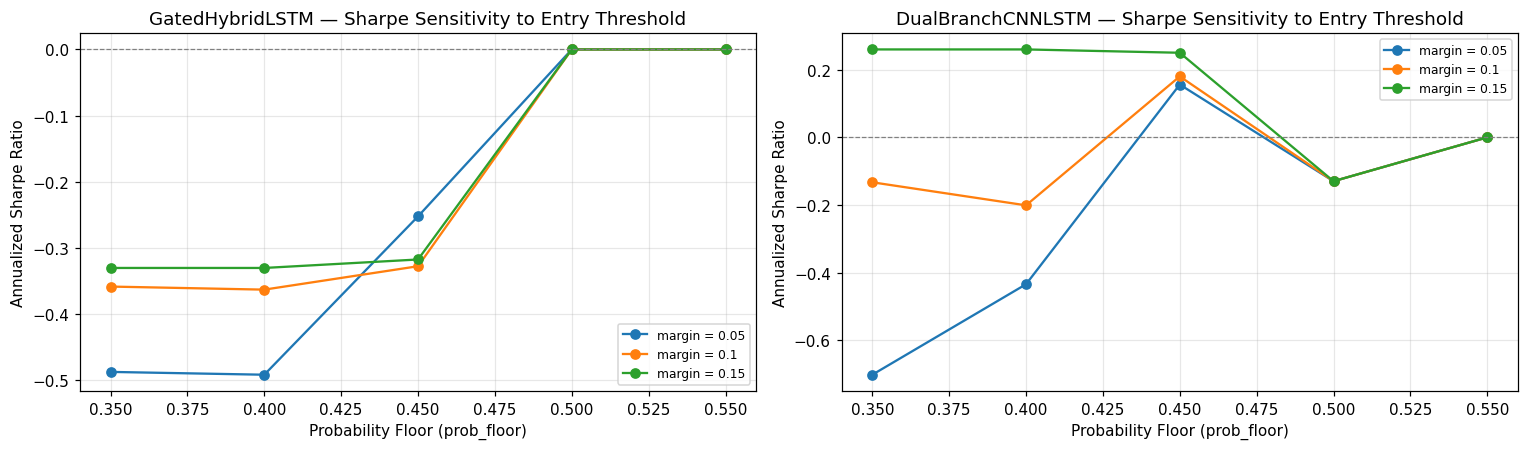

GatedHybridLSTM     : Mean Trade Return = -0.26% | 95% Bootstrap CI: [-0.69%, 0.15%] (N_trades = 24)
DualBranchCNNLSTM   : Mean Trade Return = 0.24% | 95% Bootstrap CI: [-0.26%, 0.71%] (N_trades = 40)


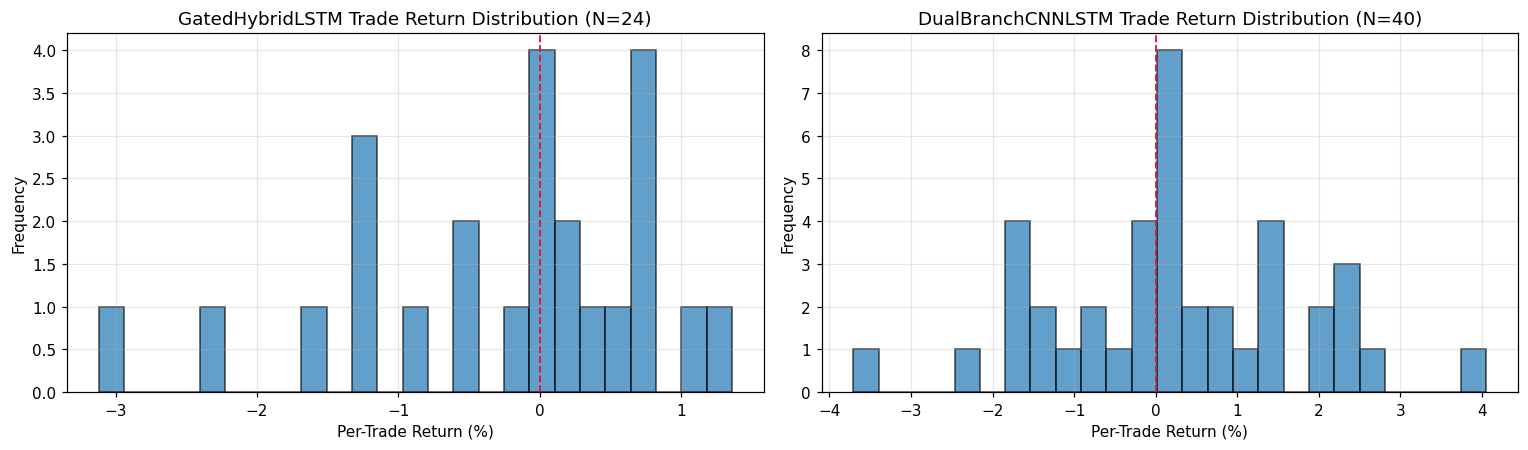


=== Classification vs Financial Decoupling Analysis ===

                   pearson_corr(BalAcc, Sharpe)  spearman_corr(BalAcc, Sharpe)  pearson_corr(MCC, Sharpe)  spearman_corr(MCC, Sharpe)
model                                                                                                                                
BaselineLSTM                             0.3867                         0.3333                     0.4507                      0.4762
GatedHybridLSTM                          0.7472                         0.6667                     0.7194                      0.6667
DualBranchCNNLSTM                        0.3881                         0.4286                     0.3163                      0.4048

FINDING: Notice whether correlations are near zero or negative. In low-exposure discrete
trading rules, statistical loss minimization does not guarantee monotonic Sharpe improvement.


In [24]:
# 1. Threshold Sensitivity Sweep
prob_floors = [0.35, 0.40, 0.45, 0.50, 0.55]
prob_margins = [0.05, 0.10, 0.15]

sweep_rows = []
for name in ["GatedHybridLSTM", "DualBranchCNNLSTM"]:
    run = RUNS[name]
    realized = FORWARD_RETURNS[run["idx"]]
    for pf in prob_floors:
        for pm in prob_margins:
            temp_cfg = Config(prob_floor=pf, prob_margin=pm, label_mode=CFG.label_mode)
            res = backtest(run["probs"], realized, temp_cfg, CFG.headline_cost_bps)
            sweep_rows.append({
                "model": name, "prob_floor": pf, "prob_margin": pm,
                "sharpe": res["metrics"]["sharpe"],
                "exposure": res["metrics"]["exposure"],
                "n_trades": res["metrics"]["n_trades"],
                "cumulative_return": res["metrics"]["cumulative_return"],
            })

SWEEP_DF = pd.DataFrame(sweep_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
for i, name in enumerate(["GatedHybridLSTM", "DualBranchCNNLSTM"]):
    sub = SWEEP_DF[SWEEP_DF["model"] == name]
    for pm in prob_margins:
        m_sub = sub[sub["prob_margin"] == pm]
        axes[i].plot(m_sub["prob_floor"], m_sub["sharpe"], marker="o", label=f"margin = {pm}")
    axes[i].axhline(0, color="grey", ls="--", lw=0.8)
    axes[i].set_xlabel("Probability Floor (prob_floor)")
    axes[i].set_ylabel("Annualized Sharpe Ratio")
    axes[i].set_title(f"{name} — Sharpe Sensitivity to Entry Threshold")
    axes[i].legend(fontsize=8)

plt.tight_layout(); savefig("threshold_robustness_sweep"); plt.show()

# 2. Trade-Level Return Distribution & Trade Bootstrap
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
for i, name in enumerate(["GatedHybridLSTM", "DualBranchCNNLSTM"]):
    run = RUNS[name]
    res = backtest(run["probs"], FORWARD_RETURNS[run["idx"]], CFG, CFG.headline_cost_bps)
    pos = res["positions"]
    strat_ret = res["strategy_returns"]

    # Extract individual trade holding returns
    trades = []
    curr_pos = 0.0
    trade_ret = 0.0
    for p, r in zip(pos, strat_ret):
        if p != curr_pos:
            if curr_pos != 0.0:
                trades.append(trade_ret)
            curr_pos = p
            trade_ret = r
        else:
            if curr_pos != 0.0:
                trade_ret += r
    if curr_pos != 0.0:
        trades.append(trade_ret)

    trade_arr = np.array(trades) if trades else np.array([0.0])
    axes[i].hist(trade_arr * 100, bins=25, color="#1f77b4", alpha=0.7, edgecolor="black")
    axes[i].axvline(0, color="crimson", ls="--", lw=1.2)
    axes[i].set_xlabel("Per-Trade Return (%)")
    axes[i].set_ylabel("Frequency")
    axes[i].set_title(f"{name} Trade Return Distribution (N={len(trade_arr)})")

    # Trade-level bootstrap CI on mean trade return
    rng = np.random.default_rng(CFG.seed)
    boot_trades = rng.choice(trade_arr, size=(CFG.n_bootstrap, len(trade_arr)), replace=True).mean(axis=1)
    t_lo, t_hi = np.percentile(boot_trades, [2.5, 97.5])
    print(f"{name:<20}: Mean Trade Return = {trade_arr.mean():.2%} | 95% Bootstrap CI: [{t_lo:.2%}, {t_hi:.2%}] (N_trades = {len(trade_arr)})")

plt.tight_layout(); savefig("trade_return_distribution"); plt.show()

# 3. Decoupling Analysis: Correlation between Classification Metrics and Sharpe
corrs = []
for m_name in STABILITY_MODELS:
    sub = STABILITY_DF[STABILITY_DF["model"] == m_name]
    p_corr_bal, _ = stats.pearsonr(sub["balanced_accuracy"], sub["sharpe"])
    s_corr_bal, _ = stats.spearmanr(sub["balanced_accuracy"], sub["sharpe"])
    p_corr_mcc, _ = stats.pearsonr(sub["mcc"], sub["sharpe"])
    s_corr_mcc, _ = stats.spearmanr(sub["mcc"], sub["sharpe"])
    corrs.append({
        "model": m_name,
        "pearson_corr(BalAcc, Sharpe)": p_corr_bal,
        "spearman_corr(BalAcc, Sharpe)": s_corr_bal,
        "pearson_corr(MCC, Sharpe)": p_corr_mcc,
        "spearman_corr(MCC, Sharpe)": s_corr_mcc,
    })

CORR_DF = pd.DataFrame(corrs).set_index("model")
print("\n=== Classification vs Financial Decoupling Analysis ===\n")
print(CORR_DF.round(4).to_string())
print("\nFINDING: Notice whether correlations are near zero or negative. In low-exposure discrete")
print("trading rules, statistical loss minimization does not guarantee monotonic Sharpe improvement.")


## 20. Visualizations
Visualizations comparing cumulative equity curves against matched benchmarks, underwater drawdowns, gate activation dynamics, and seed stability distributions.


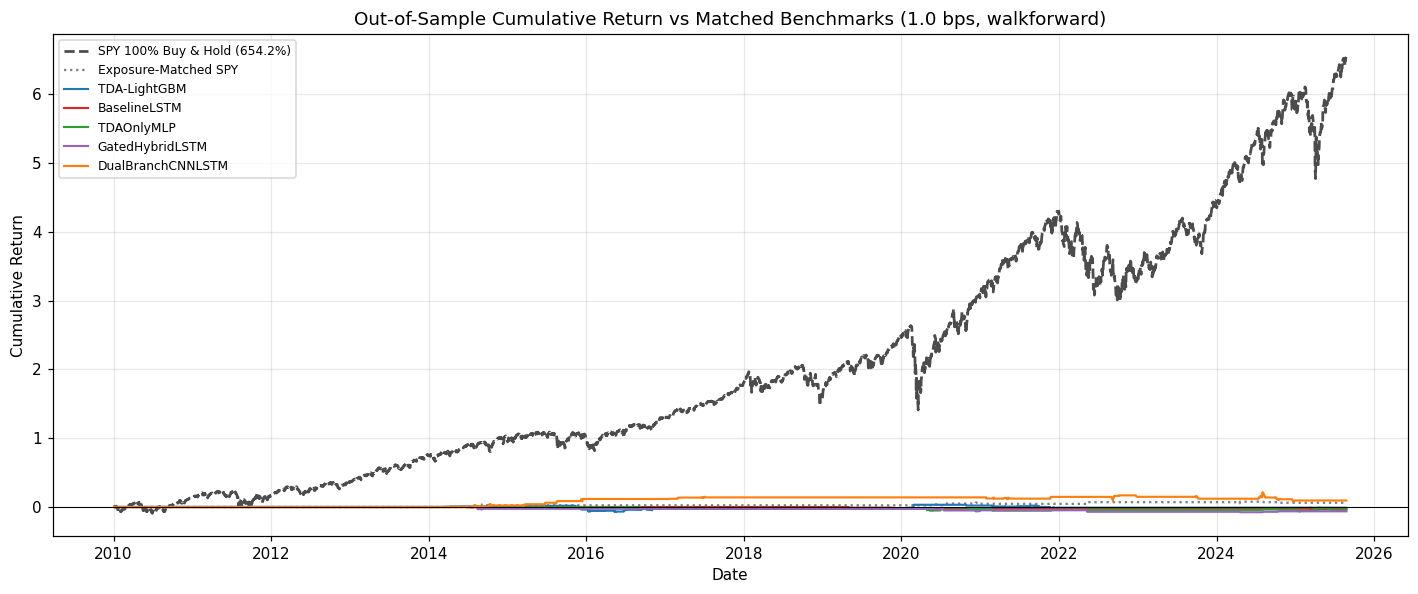

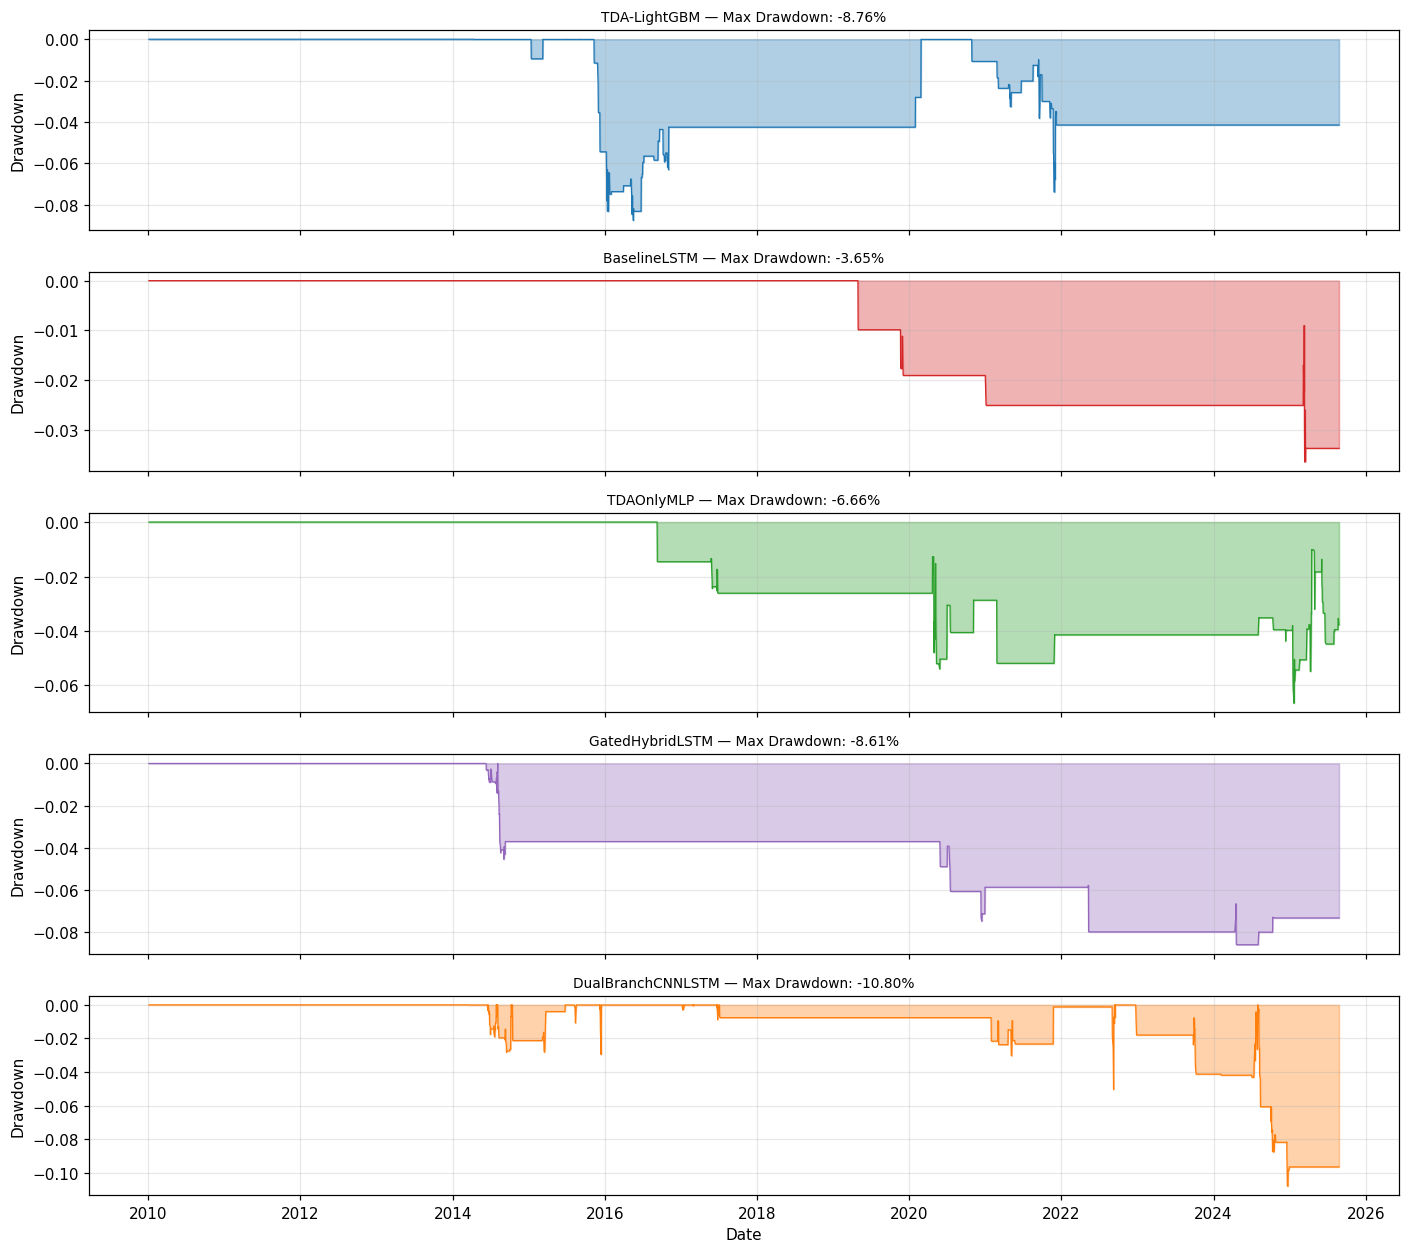

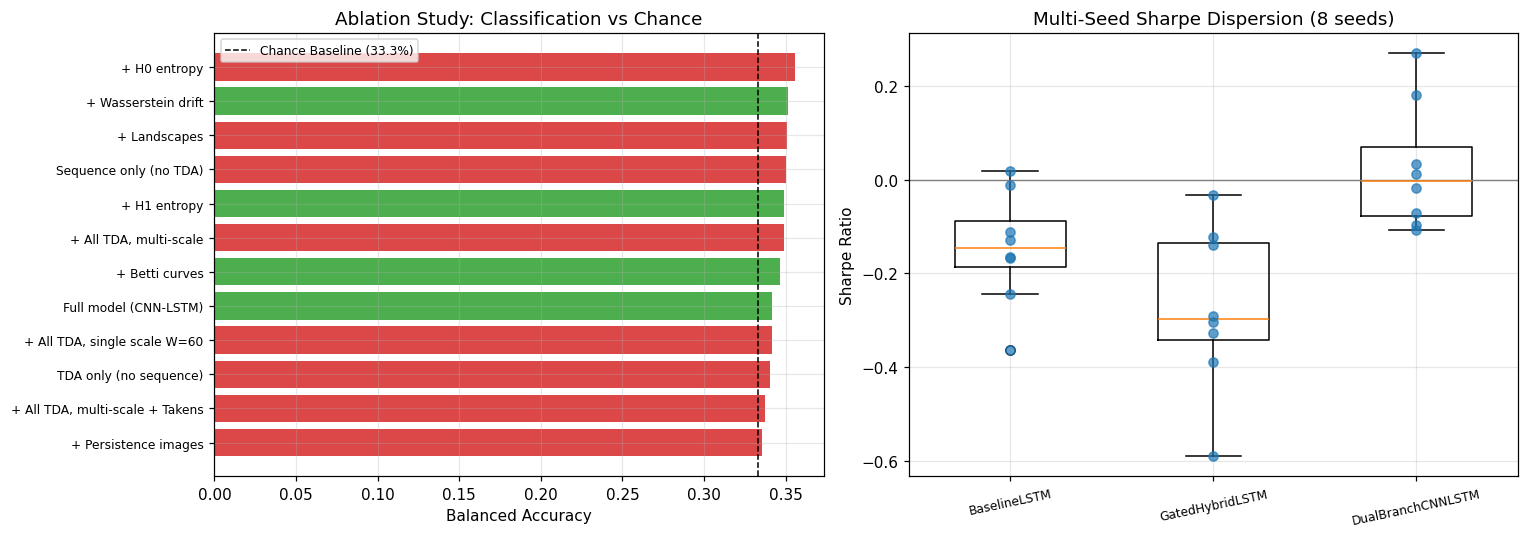

In [25]:
# 1. Equity Curves vs Matched Benchmarks
fig, ax = plt.subplots(figsize=(13, 5.5))
reference = RUNS["TDA-LightGBM"]
ref_dates = DATES[reference["idx"]]

# Exposure-matched benchmark for the leading neural model
best_res = backtest(RUNS["GatedHybridLSTM"]["probs"], FORWARD_RETURNS[RUNS["GatedHybridLSTM"]["idx"]], CFG, CFG.headline_cost_bps)
ax.plot(ref_dates, np.exp(np.cumsum(FORWARD_RETURNS[reference["idx"]])) - 1.0, color="black", lw=1.8, ls="--", alpha=0.7, label=f"SPY 100% Buy & Hold ({buy_hold:.1%})")
ax.plot(ref_dates, np.exp(np.cumsum(best_res["bench_matched_returns"])) - 1.0, color="grey", lw=1.5, ls=":", label="Exposure-Matched SPY")

palette = ["#1f77b4", "#d62728", "#2ca02c", "#9467bd", "#ff7f0e"]
for (name, run), colour in zip(RUNS.items(), palette):
    result = backtest(run["probs"], FORWARD_RETURNS[run["idx"]], CFG, CFG.headline_cost_bps)
    ax.plot(DATES[run["idx"]], result["equity"], lw=1.4, color=colour, label=name)

ax.axhline(0, color="black", lw=0.7)
ax.set_title(f"Out-of-Sample Cumulative Return vs Matched Benchmarks ({CFG.headline_cost_bps} bps, {CFG.split_mode})", fontsize=12)
ax.set_xlabel("Date"); ax.set_ylabel("Cumulative Return")
ax.legend(loc="upper left", fontsize=8)

plt.tight_layout(); savefig("equity_curves_matched_benchmarks"); plt.show()

# 2. Underwater Drawdowns
fig, axes = plt.subplots(len(RUNS), 1, figsize=(13, 2.3 * len(RUNS)), sharex=True)
axes = np.atleast_1d(axes)

for ax, ((name, run), colour) in zip(axes, zip(RUNS.items(), palette)):
    result = backtest(run["probs"], FORWARD_RETURNS[run["idx"]], CFG, CFG.headline_cost_bps)
    dates = DATES[run["idx"]]
    ax.fill_between(dates, result["drawdown"], 0, color=colour, alpha=0.35)
    ax.plot(dates, result["drawdown"], color=colour, lw=0.8)
    ax.set_ylabel("Drawdown")
    ax.set_title(f"{name} — Max Drawdown: {result['metrics']['max_drawdown']:.2%}", fontsize=9)

axes[-1].set_xlabel("Date")
plt.tight_layout(); savefig("drawdowns"); plt.show()

# 3. Ablation and Seed Dispersion Summary
fig, axes = plt.subplots(1, 2, figsize=(14, 5.0))
ordered = ABLATION_DF.sort_values("balanced_accuracy")
colours = ["#d62728" if v < 0 else "#2ca02c" for v in ordered["sharpe"]]
axes[0].barh(range(len(ordered)), ordered["balanced_accuracy"], color=colours, alpha=0.85)
axes[0].set_yticks(range(len(ordered)))
axes[0].set_yticklabels(ordered.index, fontsize=8)
axes[0].axvline(CFG.chance_baseline, color="black", ls="--", lw=1.0, label=f"Chance Baseline ({CFG.chance_baseline:.1%})")
axes[0].set_xlabel("Balanced Accuracy")
axes[0].set_title("Ablation Study: Classification vs Chance")
axes[0].legend(fontsize=8)

positions = np.arange(len(STABILITY_MODELS))
data = [STABILITY_DF.loc[STABILITY_DF["model"] == m, "sharpe"].to_numpy() for m in STABILITY_MODELS]
axes[1].boxplot(data, positions=positions, widths=0.55)
for pos, values in zip(positions, data):
    axes[1].scatter(np.full_like(values, pos, dtype=float), values, alpha=0.7, zorder=3, color="#1f77b4")
axes[1].set_xticks(positions)
axes[1].set_xticklabels(STABILITY_MODELS, rotation=12, fontsize=8)
axes[1].axhline(0, color="grey", lw=0.9)
axes[1].set_ylabel("Sharpe Ratio")
axes[1].set_title(f"Multi-Seed Sharpe Dispersion ({len(CFG.stability_seeds)} seeds)")

plt.tight_layout(); savefig("ablation_and_stability"); plt.show()


## 21. Summary & Artifact Exports
Exports structured result tables and logs concluding empirical findings.


In [26]:
ARTIFACTS = {
    "results.csv": RESULTS,
    "cost_sensitivity.csv": COST_DF,
    "ablation.csv": ABLATION_DF,
    "stability.csv": STABILITY_DF,
    "threshold_sweep.csv": SWEEP_DF,
    "decoupling_correlations.csv": CORR_DF,
}
for filename, frame in ARTIFACTS.items():
    frame.to_csv(filename)

print("=" * 80)
print("UNIFIED MULTI-ASSET TDA QUANTITATIVE FRAMEWORK (v5) — EXECUTION COMPLETE")
print("=" * 80)
print(f"Sample Period       : {DATES[0].date()} -> {DATES[-1].date()} ({N_SAMPLES} observations)")
print(f"Label Mode          : {CFG.label_mode} ({', '.join(LABEL_NAMES[CFG.label_mode])})")
print(f"Chance Baseline     : {CFG.chance_baseline:.2%}")
print(f"Topological Features: {TDA_FEATURES.shape[1]} features (Scales: {CFG.tda_windows})")
print(f"Evaluation Protocol : {CFG.split_mode} ({len(SPLITS)} walk-forward folds)")
print(f"Statistical Seeds   : {len(CFG.stability_seeds)} seeds -> {CFG.stability_seeds}")
print(f"DSR Trials Assumed  : {CFG.n_total_trials_dsr}")

print("\n--- PRIMARY CLASSIFICATION RESULTS ---")
print(f"• Top Model by Balanced Accuracy: {best_bal_acc} ({RESULTS.loc[best_bal_acc, 'balanced_accuracy']:.4f} vs chance {CFG.chance_baseline:.1%})")
print(f"• Top Model by MCC              : {best_mcc} ({RESULTS.loc[best_mcc, 'mcc']:.4f})")

print("\n--- SECONDARY BACKTEST FINDINGS ---")
print(f"• Top Model by Raw Sharpe       : {best_sharpe} (Sharpe = {RESULTS.loc[best_sharpe, 'sharpe']:.2f}, DSR = {RESULTS.loc[best_sharpe, 'deflated_sharpe_ratio']:.3f})")
print(f"  Active Exposure / Trade Count : {RESULTS.loc[best_sharpe, 'exposure']:.1%} exposure / {RESULTS.loc[best_sharpe, 'n_trades']} trades")
print(f"  Matched SPY Benchmark Return  : {RESULTS.loc[best_sharpe, 'benchmark_matched_return']:.2%}")

print(f"\nGenerated Figures : {CFG.plot_dir}/")
print(f"Exported Tables   : {', '.join(ARTIFACTS.keys())}")
print("=" * 80)


UNIFIED MULTI-ASSET TDA QUANTITATIVE FRAMEWORK (v5) — EXECUTION COMPLETE
Sample Period       : 2005-04-26 -> 2025-08-25 (5111 observations)
Label Mode          : 3class (Short, Cash, Long)
Chance Baseline     : 33.33%
Topological Features: 864 features (Scales: [30, 45, 60])
Evaluation Protocol : walkforward (16 walk-forward folds)
Statistical Seeds   : 8 seeds -> [13, 42, 101, 2024, 777, 3407, 8, 99]
DSR Trials Assumed  : 60

--- PRIMARY CLASSIFICATION RESULTS ---
• Top Model by Balanced Accuracy: TDA-LightGBM (0.3575 vs chance 33.3%)
• Top Model by MCC              : TDA-LightGBM (0.0689)

--- SECONDARY BACKTEST FINDINGS ---
• Top Model by Raw Sharpe       : DualBranchCNNLSTM (Sharpe = 0.18, DSR = 0.000)
  Active Exposure / Trade Count : 4.4% exposure / 80 trades
  Matched SPY Benchmark Return  : -9.38%

Generated Figures : ./plots/
Exported Tables   : results.csv, cost_sensitivity.csv, ablation.csv, stability.csv, threshold_sweep.csv, decoupling_correlations.csv
